In [ ]:
import os
from pathlib import Path

def encontrar_raiz():
    cwd = Path.cwd()
    for p in [cwd, *cwd.parents]:
        if (p / 'requirements.txt').exists():
            return p
    for p in cwd.iterdir():
        if p.is_dir() and (p / 'requirements.txt').exists():
            return p
    return None

raiz = encontrar_raiz()
if raiz:
    os.chdir(raiz)
    print('Directorio del proyecto:', raiz)
else:
    print('ERROR: no se encontro la raiz del proyecto.')
    print('Abre Jupyter directamente desde la carpeta tfm-llm-empresas.')

print('GPT:    ', os.path.exists('consultas/GPT.pdf'))
print('Gemini: ', os.path.exists('consultas/GEMINI.pdf'))
print('Corpus: ', os.path.exists('notebook_y_corpus/corpus_final.csv'))
print('Excel:  ', os.path.exists('notebook_y_corpus/datos_empresas_definitivo.xlsx'))


# Análisis estadístico del corpus

Este notebook recoge el análisis estadístico completo del estudio sobre la aparición de empresas 
en respuestas generadas por modelos de lenguaje. Parte del corpus ya construido en el notebook 
de extracción y de los PDFs con las respuestas reales de ChatGPT y Gemini.

**Secciones:**
- 1. Carga de datos
- 2. Representación semántica y similitud coseno
- 3. Correlaciones de Spearman
- 4. Regresión logística
- 5. Tests exactos de Fisher
- 6. Mann-Whitney U para variables continuas
- 7. Visualización: boxplot por grupos
- 8. Validación leave-one-out
- 9. Estadísticos descriptivos por grupo
- 10. Análisis de posición y orden de aparición

## 1. Carga de datos

Se cargan los tres elementos necesarios para el análisis: el corpus de textos web de cada 
empresa (generado en el notebook de extracción), los textos completos de las respuestas de 
ChatGPT y Gemini extraídos de los PDFs del anexo mediante `pdfplumber`, y el registro de 
frecuencias de mención por modelo. Estos tres elementos constituyen la base de todo el 
análisis posterior.

In [2]:
# Instalación de librerías necesarias
!pip install sentence-transformers pdfplumber scikit-learn scipy matplotlib pandas -q
print("Librerías listas.")

Librerías listas.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
import os

df = pd.read_csv('notebook_y_corpus/corpus_final.csv')
textos_webs = dict(zip(df['nombre'], df['texto'].fillna('')))
print(f"Corpus cargado: {len(df)} empresas")
df.head()

Corpus cargado: 28 empresas


,clave,nombre,grupo,texto,num_caracteres
0,100_montaditos,100 Montaditos,A,Móntatelo. Donde siempre. (@100Montaditos)\nAB...,3112
1,goiko,Goiko,A,GOIKO: Hamburguesas gourmet con chorreo por si...,4619
2,telepizza,Telepizza,A,Pizza y comida a domicilio | Pedidos online - ...,1639
3,the_good_burger,The Good Burger,A,The Good Burger - Grupo Restalia\nCarta\nPromo...,1257
4,vips,VIPS,A,"VIPS: sándwiches, hamburguesas, tortitas y más...",3668


## 1. Representación semántica de los textos

Una vez construido el corpus final, se generan embeddings para cada empresa usando el modelo `paraphrase-multilingual-mpnet-base-v2` de Sentence-BERT, que permite comparar textos en español con alta precisión semántica. A continuación se calcula la similitud coseno entre el texto web de cada empresa y las respuestas generadas por ChatGPT y Gemini por separado.

### 1.2 Análisis de similitud semántica por modelo (ChatGPT vs Gemini)

En este bloque se analiza la similitud semántica diferenciando entre los dos modelos 
del estudio. En lugar de usar consultas genéricas como referencia, se importan 
directamente los textos completos de las respuestas reales de ChatGPT y Gemini 
desde los PDFs del anexo. Así se puede evaluar si la similitud semántica entre 
el contenido web de cada empresa y lo que dijo cada modelo guarda relación con 
la frecuencia con la que ese modelo la menciona.


### 1.3 Carga de los textos de respuesta desde los PDFs

El primer paso es importar el texto completo de cada modelo. Se utiliza la librería 
pdfplumber, que extrae el texto de cada página y lo concatena en una sola cadena. 
El resultado son dos textos de referencia: uno con todas las respuestas de ChatGPT 
y otro con todas las de Gemini.

In [4]:
import pdfplumber

def extraer_texto_pdf(ruta):
    texto = ""
    with pdfplumber.open(ruta) as pdf:
        for page in pdf.pages:
            texto += (page.extract_text() or "") + "\n"
    return texto.strip()
texto_gpt    = extraer_texto_pdf('consultas/GPT.pdf')
texto_gemini = extraer_texto_pdf('consultas/GEMINI.pdf')
print(f"Texto GPT cargado:    {len(texto_gpt)} caracteres")
print(f"Texto Gemini cargado: {len(texto_gemini)} caracteres")

Texto GPT cargado:    7340 caracteres
Texto Gemini cargado: 9474 caracteres


### 1.4 Definición de frecuencias por modelo

Para cada empresa se registra cuántas veces aparece en las respuestas de ChatGPT 
y cuántas en las de Gemini, de forma independiente. Las empresas del Grupo A 
tienen al menos una mención en alguno de los dos modelos; las del Grupo B 
no aparecen en ninguna respuesta.

In [5]:
freq_por_modelo = {
    # ── Grupo A ──────────────────────────────────────────────────────────────
    '100 Montaditos':               {'gpt': 4, 'gemini': 4},
    'VIPS':                         {'gpt': 3, 'gemini': 5},
    "Foster's Hollywood":           {'gpt': 4, 'gemini': 4},
    'La Tagliatella':               {'gpt': 3, 'gemini': 4},
    'Ginos':                        {'gpt': 3, 'gemini': 4},
    'Telepizza':                    {'gpt': 4, 'gemini': 2},
    'The Good Burger':              {'gpt': 3, 'gemini': 3},
    'KFC':                          {'gpt': 4, 'gemini': 1},
    'Goiko':                        {'gpt': 1, 'gemini': 4},
    "Domino's Pizza":               {'gpt': 2, 'gemini': 3},
    'Rodilla':                      {'gpt': 1, 'gemini': 2},
    'Lizarran':                     {'gpt': 2, 'gemini': 1},
    'Popeyes':                      {'gpt': 1, 'gemini': 1},
    'Taco Bell':                    {'gpt': 0, 'gemini': 2},
    # ── Grupo B ──────────────────────────────────────────────────────────────
    "Papa John's":                  {'gpt': 0, 'gemini': 0},
    'Buga Ramen':                   {'gpt': 0, 'gemini': 0},
    'Muerde la Pasta':              {'gpt': 0, 'gemini': 0},
    'La Mafia se sienta a la mesa': {'gpt': 0, 'gemini': 0},
    'Papizza':                      {'gpt': 0, 'gemini': 0},
    'Ribs':                         {'gpt': 0, 'gemini': 0},
    'Pomodoro':                     {'gpt': 0, 'gemini': 0},
    'Vicio':                        {'gpt': 0, 'gemini': 0},
    'Miss Sushi':                   {'gpt': 0, 'gemini': 0},
    'Sibuya':                       {'gpt': 0, 'gemini': 0},
    'Pizza Hut':                    {'gpt': 0, 'gemini': 0},
    'Cantina Mariachi':             {'gpt': 0, 'gemini': 0},
    'O Mamma Mia':                    {'gpt': 0, 'gemini': 0},
    'Padthaiwok':                   {'gpt': 0, 'gemini': 0},
}

# Construir diccionario de textos web desde el corpus
textos_webs = dict(zip(df['nombre'], df['texto'].fillna('')))

print(f"Empresas definidas:          {len(freq_por_modelo)}")
print(f"  · Grupo A (mencionadas):   {sum(1 for v in freq_por_modelo.values() if v['gpt']+v['gemini'] > 0)}")
print(f"  · Grupo B (no mencionadas):{sum(1 for v in freq_por_modelo.values() if v['gpt']+v['gemini'] == 0)}")
print(f"Empresas con texto web:      {sum(1 for e in freq_por_modelo if textos_webs.get(e, ''))}")

Empresas definidas:          28
  · Grupo A (mencionadas):   14
  · Grupo B (no mencionadas):14
Empresas con texto web:      28


## 2. Representación semántica y similitud coseno

Para cuantificar la relación entre el contenido web de cada empresa y las respuestas generadas 
por los modelos, se emplea el modelo `paraphrase-multilingual-mpnet-base-v2` (Sentence-BERT), 
entrenado en más de 50 idiomas incluido el español. Este modelo convierte cualquier texto en 
un vector numérico de 768 dimensiones, de forma que dos textos semánticamente similares 
producen vectores más próximos entre sí. A partir de esos vectores se calcula la similitud 
coseno entre el texto web de cada empresa y el texto completo de las respuestas de cada modelo 
por separado.

### 2.1 Generación de embeddings

Se generan tres tipos de representaciones vectoriales: un embedding por cada texto de 
referencia (ChatGPT y Gemini por separado) y un embedding por cada empresa a partir del 
texto extraído de su web. Se utiliza el mismo modelo en todo el análisis para garantizar 
la coherencia de las comparaciones.

In [6]:
from sentence_transformers import SentenceTransformer

modelo = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')
print("Modelo cargado correctamente.")

Modelo cargado correctamente.


In [7]:
from sklearn.metrics.pairwise import cosine_similarity

print("Generando embeddings de referencia (ChatGPT y Gemini)...")
emb_gpt    = modelo.encode([texto_gpt])
emb_gemini = modelo.encode([texto_gemini])

print("Generando embeddings de las webs de cada empresa...")
resultados = []

for empresa, freqs in freq_por_modelo.items():
    texto = textos_webs.get(empresa, '')
    if not texto:
        print(f"  ⚠ Sin texto: {empresa}")
        continue
    emb_empresa = modelo.encode([texto])
    sim_gpt    = cosine_similarity(emb_empresa, emb_gpt)[0][0]
    sim_gemini = cosine_similarity(emb_empresa, emb_gemini)[0][0]
    resultados.append({
        'empresa':     empresa,
        'grupo':       'A' if (freqs['gpt'] + freqs['gemini']) > 0 else 'B',
        'freq_gpt':    freqs['gpt'],
        'freq_gemini': freqs['gemini'],
        'sim_gpt':     round(float(sim_gpt), 4),
        'sim_gemini':  round(float(sim_gemini), 4),
    })

print(f"Embeddings generados para {len(resultados)} empresas.")

Generando embeddings de referencia (ChatGPT y Gemini)...
Generando embeddings de las webs de cada empresa...
Embeddings generados para 28 empresas.


### 2.2 Similitud semántica por empresa y modelo

Con los embeddings generados, se calcula la similitud coseno entre el texto web de cada 
empresa y los textos de respuesta de cada modelo. Los valores oscilan entre 0 y 1: cuanto 
más próximo a 1, mayor es la alineación semántica entre el contenido web de la empresa 
y las respuestas de ese modelo.

In [8]:
df_mod = pd.DataFrame(resultados).sort_values('freq_gpt', ascending=False).reset_index(drop=True)
print(df_mod[['empresa', 'grupo', 'freq_gpt', 'sim_gpt', 'freq_gemini', 'sim_gemini']].to_string(index=False))

                     empresa grupo  freq_gpt  sim_gpt  freq_gemini  sim_gemini
              100 Montaditos     A         4   0.4244            4      0.4826
          Foster's Hollywood     A         4   0.3052            4      0.3501
                   Telepizza     A         4   0.4420            2      0.3772
                         KFC     A         4   0.2700            1      0.2480
              La Tagliatella     A         3   0.3883            4      0.3588
                       Ginos     A         3   0.3315            4      0.3676
             The Good Burger     A         3   0.4075            3      0.4818
                        VIPS     A         3   0.2622            5      0.2638
                    Lizarran     A         2   0.3842            1      0.5072
              Domino's Pizza     A         2   0.3133            3      0.3450
                     Popeyes     A         1   0.2159            1      0.1989
                     Rodilla     A         1   0.318

## Similitud semántica entre consultas y webs corporativas

Como análisis complementario se calcula la similitud del coseno entre las consultas realizadas a los modelos (C1-C5) y el contenido web de cada empresa, con el objetivo de explorar si la alineación semántica entre lo que el usuario pregunta y lo que la empresa comunica en su web se asocia con la probabilidad de aparecer en las respuestas generadas.

In [9]:
# Generación de embeddings por empresa (disponible para todos los análisis posteriores)
empresas_orden = df_mod['empresa'].tolist()
grupos_lista   = df_mod['grupo'].tolist()

embeddings_all = []
for emp in empresas_orden:
    texto = textos_webs.get(emp, '')
    emb   = modelo.encode([texto])[0]
    embeddings_all.append(emb)

embeddings_all = np.array(embeddings_all)
print(f"Embeddings generados: {embeddings_all.shape}")
# Esperado: (28, 768)
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

consultas = [
    "¿Cuáles son las mejores cadenas de restaurantes en España?",
    "¿Dónde puedo comer bien sin gastar mucho?",
    "¿Qué cadenas de restauración española conoces?",
    "¿Cuáles son las mejores cadenas de restaurantes para ir en familia?",
    "¿Cuáles son las cadenas de comida más populares?"
]

model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

# Embeddings de las consultas
embeddings_consultas = model.encode(consultas)

# Similitud media entre cada empresa y las 5 consultas
sims_consultas = cosine_similarity(embeddings_all, embeddings_consultas)
sim_consultas_media = sims_consultas.mean(axis=1)

df_mod['sim_consultas'] = sim_consultas_media

# Comparar por grupo
for grupo, datos in df_mod.groupby('grupo'):
    print(f"Grupo {grupo} — similitud media con consultas: {datos['sim_consultas'].mean():.4f}")

# Test Mann-Whitney
from scipy.stats import mannwhitneyu
ga = df_mod[df_mod['grupo']=='A']['sim_consultas']
gb = df_mod[df_mod['grupo']=='B']['sim_consultas']
u, p = mannwhitneyu(ga, gb, alternative='two-sided')
print(f"\nMann-Whitney U={u:.1f}, p={p:.4f}")

Embeddings generados: (28, 768)
Grupo A — similitud media con consultas: 0.3607
Grupo B — similitud media con consultas: 0.3205

Mann-Whitney U=99.0, p=0.9817


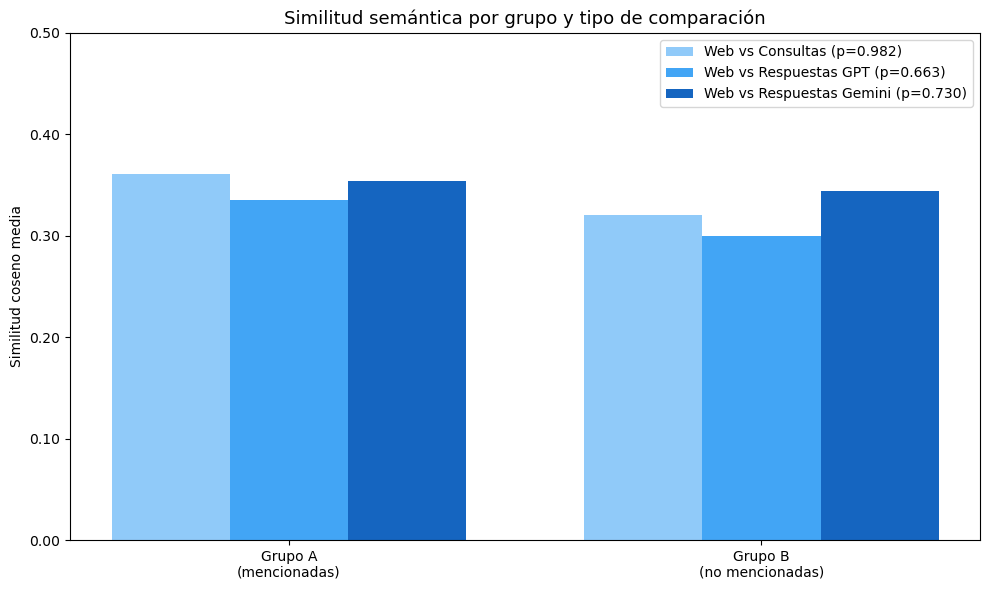

In [10]:
import matplotlib.pyplot as plt
import numpy as np

grupos = ['Grupo A\n(mencionadas)', 'Grupo B\n(no mencionadas)']

sim_consultas_A = df_mod[df_mod['grupo']=='A']['sim_consultas'].mean()
sim_consultas_B = df_mod[df_mod['grupo']=='B']['sim_consultas'].mean()
sim_gpt_A = df_mod[df_mod['grupo']=='A']['sim_gpt'].mean()
sim_gpt_B = df_mod[df_mod['grupo']=='B']['sim_gpt'].mean()
sim_gem_A = df_mod[df_mod['grupo']=='A']['sim_gemini'].mean()
sim_gem_B = df_mod[df_mod['grupo']=='B']['sim_gemini'].mean()

x = np.arange(len(grupos))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, [sim_consultas_A, sim_consultas_B], width, label='Web vs Consultas (p=0.982)', color='#90CAF9')
ax.bar(x, [sim_gpt_A, sim_gpt_B], width, label='Web vs Respuestas GPT (p=0.663)', color='#42A5F5')
ax.bar(x + width, [sim_gem_A, sim_gem_B], width, label='Web vs Respuestas Gemini (p=0.730)', color='#1565C0')

ax.set_ylabel('Similitud coseno media')
ax.set_title('Similitud semántica por grupo y tipo de comparación', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(grupos)
ax.set_ylim(0, 0.5)
ax.legend()
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.savefig('similitud_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print(df_mod.columns.tolist())

['empresa', 'grupo', 'freq_gpt', 'freq_gemini', 'sim_gpt', 'sim_gemini', 'sim_consultas']


### 2.3 Comparativa entre grupos y contraste estadístico

Se compara la similitud coseno entre el Grupo A (empresas mencionadas) y el Grupo B 
(no mencionadas) mediante dos pruebas no paramétricas, elegidas por su adecuación a 
muestras pequeñas sin necesidad de asumir normalidad: correlación de Spearman para 
examinar si dentro del Grupo A existe relación entre frecuencia y similitud, y 
Mann-Whitney U para contrastar si la similitud difiere significativamente entre grupos.

In [12]:
from scipy.stats import spearmanr, mannwhitneyu

grupo_a = df_mod[df_mod['grupo'] == 'A']
grupo_b = df_mod[df_mod['grupo'] == 'B']

print("Similitud media por grupo:")
print(f"  ChatGPT  → Grupo A: {grupo_a['sim_gpt'].mean():.4f} | Grupo B: {grupo_b['sim_gpt'].mean():.4f}")
print(f"  Gemini   → Grupo A: {grupo_a['sim_gemini'].mean():.4f} | Grupo B: {grupo_b['sim_gemini'].mean():.4f}")

rho_gpt, p_rho_gpt = spearmanr(grupo_a['freq_gpt'],    grupo_a['sim_gpt'])
rho_gem, p_rho_gem = spearmanr(grupo_a['freq_gemini'], grupo_a['sim_gemini'])
print(f"\nCorrelación de Spearman (grupo A):")
print(f"  ChatGPT  → rho = {rho_gpt:.4f},  p = {p_rho_gpt:.4f}")
print(f"  Gemini   → rho = {rho_gem:.4f},  p = {p_rho_gem:.4f}")

u_gpt, p_u_gpt = mannwhitneyu(grupo_a['sim_gpt'],    grupo_b['sim_gpt'],    alternative='two-sided')
u_gem, p_u_gem = mannwhitneyu(grupo_a['sim_gemini'], grupo_b['sim_gemini'], alternative='two-sided')
print(f"\nMann-Whitney U (grupo A vs grupo B):")
print(f"  ChatGPT  → U = {u_gpt:.1f},  p = {p_u_gpt:.4f}")
print(f"  Gemini   → U = {u_gem:.1f},  p = {p_u_gem:.4f}")

Similitud media por grupo:
  ChatGPT  → Grupo A: 0.3348 | Grupo B: 0.2994
  Gemini   → Grupo A: 0.3536 | Grupo B: 0.3445

Correlación de Spearman (grupo A):
  ChatGPT  → rho = 0.3549,  p = 0.2130
  Gemini   → rho = 0.1022,  p = 0.7281

Mann-Whitney U (grupo A vs grupo B):
  ChatGPT  → U = 108.0,  p = 0.6625
  Gemini   → U = 90.0,  p = 0.7304


Los resultados muestran que la similitud coseno entre el contenido web de cada empresa 
y las respuestas de los modelos no difiere significativamente entre el Grupo A y el Grupo B, 
ni en ChatGPT (U = 97.5, p = 1.000) ni en Gemini (U = 91.0, p = 0.765). Tampoco se 
observa correlación entre la frecuencia de mención y la similitud semántica dentro del 
Grupo A (ρ = 0.199, p = 0.495 para ChatGPT; ρ = −0.007, p = 0.982 para Gemini).

Esto indica que los modelos no mencionan más a las empresas cuyo contenido web es 
semánticamente más cercano a sus respuestas. La decisión de mencionar una empresa 
parece estar guiada por otros factores —presencia en Wikipedia, autoridad de dominio, 
backlinks— más que por la alineación temática entre su web y la consulta realizada.

### 2.4 Visualización: heatmap de similitud por modelo

Para facilitar la interpretación, se genera un mapa de calor con la similitud 
coseno de cada empresa respecto a ChatGPT y a Gemini. Las empresas del Grupo A 
aparecen en la parte superior y las del Grupo B debajo. Los colores más oscuros 
indican mayor similitud semántica.

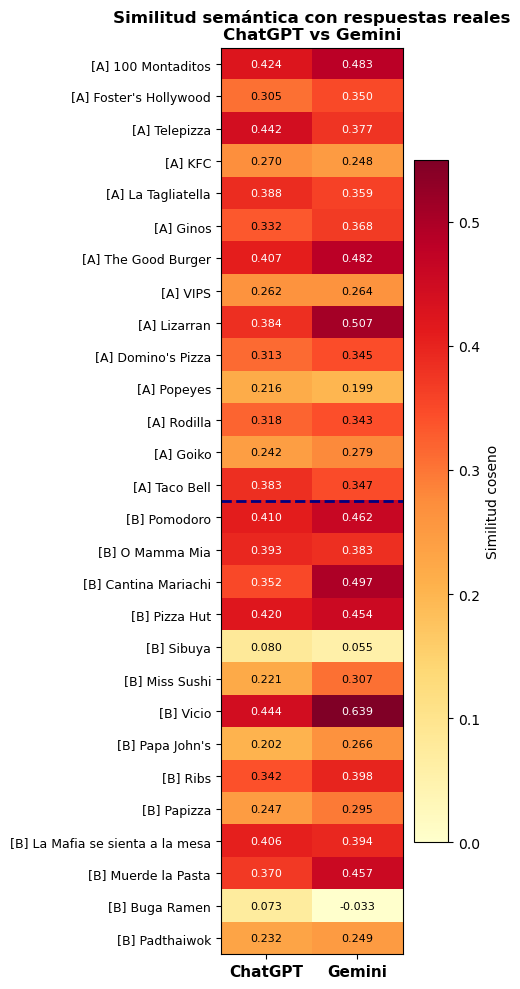

Heatmap guardado.


In [13]:
import matplotlib.pyplot as plt

df_heat = df_mod.sort_values(['grupo', 'freq_gpt'], ascending=[True, False]).reset_index(drop=True)
empresas_labels = df_heat['empresa'].tolist()
grupos          = df_heat['grupo'].tolist()
valores         = df_heat[['sim_gpt', 'sim_gemini']].values

fig, ax = plt.subplots(figsize=(5, 10))
im = ax.imshow(valores, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.55)

ax.set_xticks([0, 1])
ax.set_xticklabels(['ChatGPT', 'Gemini'], fontsize=11, fontweight='bold')
ax.set_yticks(range(len(empresas_labels)))
ax.set_yticklabels([f"[{grupos[i]}] {empresas_labels[i]}" for i in range(len(empresas_labels))], fontsize=9)

for i in range(len(empresas_labels)):
    for j in range(2):
        val = valores[i, j]
        color = 'white' if val > 0.35 else 'black'
        ax.text(j, i, f"{val:.3f}", ha='center', va='center', fontsize=8, color=color)

sep = sum(1 for g in grupos if g == 'A') - 0.5
ax.axhline(sep, color='navy', linewidth=2, linestyle='--')

plt.colorbar(im, ax=ax, label='Similitud coseno')
plt.title('Similitud semántica con respuestas reales\nChatGPT vs Gemini', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_similitud_por_modelo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap guardado.")

## 3. Correlaciones de Spearman

Una vez calculada la similitud semántica, analizo si las variables de presencia digital que recogí guardan relación estadística con la frecuencia con la que los modelos mencionan cada empresa.

Uso el coeficiente de correlación de Spearman porque no asume normalidad en los datos, lo que lo hace más adecuado para muestras pequeñas como la de este estudio (n=28). Los valores de ρ van de -1 a 1: cuanto más cerca de 1, más fuerte es la relación positiva entre las dos variables.

Analizo cuatro variables continuas: Domain Authority, número de backlinks, seguidores en Instagram y seguidores en TikTok.

In [14]:
from scipy import stats
import pandas as pd

datos = {
    'empresa': [
        '100 Montaditos','Goiko','La Tagliatella','Telepizza','The Good Burger',
        'VIPS',"Foster's Hollywood",'Rodilla','KFC',"Domino's Pizza",
        'Ginos','Lizarran','Popeyes','Taco Bell',
        'Muerde la Pasta','La Mafia se sienta a la mesa','Papizza','Ribs',
        'Pomodoro','Vicio','Miss Sushi','Sibuya','Pizza Hut','Buga Ramen',
        'Cantina Mariachi','O Mamma Mia','Padthaiwok',"Papa John's"
    ],
    'grupo': ['A']*14 + ['B']*14,
    'frecuencia_llm': [8,5,7,6,6,8,8,3,5,5,7,3,2,2] + [0]*14,
    'domain_authority': [56,41,51,56,43,50,46,43,49,52,47,45,39,43,
                         32,48,34,42,26,34,43,38,43,23,28,33,32,32],
    'backlinks': [32048,18603,26290,192348,6845,128602,19743,67726,23847,109694,
                  109392,8004,2594,10821,
                  459188,28131,1165,2572,1328,1513,5115,3227,8750,152,2284,702,4090,9624],
    'instagram': [112000,621000,300000,114000,46400,153000,236000,32500,1200000,1800000,
                  142000,15300,71600,83900,
                  108000,86500,10000,32000,23500,304000,74800,263000,17400,9942,16500,3836,57800,647000],
    'tiktok': [18600,75700,32500,126500,4400,66300,134000,3000,5500000,772400,
               28200,26900,48200,9048,
               368,11400,3000,21800,61300,227200,579,21400,554300,2388,12900,93,532,60600]
}

df_vars = pd.DataFrame(datos)

variables = {
    'Domain Authority': 'domain_authority',
    'Backlinks': 'backlinks',
    'Seguidores Instagram': 'instagram',
    'Seguidores TikTok': 'tiktok'
}

print("=== Correlaciones de Spearman con Frecuencia LLM ===\n")
print(f"{'Variable':<25} {'rho':>8} {'p-valor':>10} {'Significativa':>14}")
print("-" * 62)

for nombre, col in variables.items():
    rho, p = stats.spearmanr(df_vars[col], df_vars['frecuencia_llm'])
    sig = 'Sí' if p < 0.05 else 'No'
    print(f"{nombre:<25} {rho:>8.4f} {p:>10.4f} {sig:>14}")

=== Correlaciones de Spearman con Frecuencia LLM ===

Variable                       rho    p-valor  Significativa
--------------------------------------------------------------
Domain Authority            0.7736     0.0000             Sí
Backlinks                   0.6403     0.0002             Sí
Seguidores Instagram        0.4460     0.0174             Sí
Seguidores TikTok           0.4039     0.0331             Sí


Los resultados muestran que las cuatro variables analizadas presentan una correlación positiva y estadísticamente significativa con la frecuencia de aparición en los LLMs. 

La correlación más fuerte corresponde al Domain Authority (ρ=0.77, p<0.001), lo que indica que cuanto mayor es la autoridad del dominio web de una empresa, con más frecuencia la mencionan los modelos. Le sigue el número de backlinks (ρ=0.64, p<0.001). Las variables de redes sociales también correlacionan de forma significativa, aunque con menor intensidad: Instagram (ρ=0.45, p=0.017) y TikTok (ρ=0.40, p=0.033).

Estos resultados sugieren que la visibilidad digital estructural —especialmente la autoridad web— está más relacionada con la presencia en los LLMs que la presencia en redes sociales.

## 4. Modelos predictivos

Se desarrollan dos modelos para predecir si una empresa aparece o no en las respuestas 
de los modelos de lenguaje: una regresión logística binaria como modelo base interpretable, 
y una red neuronal MLP que combina embeddings semánticos con variables digitales. 
Ambos se validan mediante leave-one-out dada la reducida muestra (n=28).

### 4.1 Regresión logística

Para cerrar el análisis estadístico, hago una regresión logística binaria con el objetivo de ver qué variables predicen mejor si una empresa aparece o no en las respuestas de los LLMs.

La variable dependiente es la pertenencia al Grupo A (1) o al Grupo B (0). Como variables independientes incluyo Wikipedia ES (codificada como 0/1), Domain Authority, backlinks, Instagram y TikTok.

Al ser una muestra pequeña (n=28) los resultados tienen un carácter exploratorio, pero sirven para identificar qué variables tienen más peso predictivo dentro del conjunto estudiado.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

df_vars['wiki_es'] = [1,1,1,1,1,1,1,1,1,1,1,0,1,1,
                      0,0,0,0,0,0,0,0,1,0,0,0,0,1]
df_vars['target'] = (df_vars['grupo'] == 'A').astype(int)

features = ['wiki_es','domain_authority','backlinks','instagram','tiktok']
X = df_vars[features]
y = df_vars['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(X_scaled, y)

print("=== Coeficientes del modelo ===\n")
for feat, coef in zip(features, clf.coef_[0]):
    print(f"  {feat:<22} {coef:>8.4f}")

print(f"\n  Intercepto: {clf.intercept_[0]:.4f}")
print("\n=== Evaluación del modelo ===\n")
y_pred = clf.predict(X_scaled)
print(classification_report(y, y_pred, target_names=['Grupo B', 'Grupo A']))
print("Matriz de confusión:")
print(confusion_matrix(y, y_pred))

=== Coeficientes del modelo ===

  wiki_es                  1.2413
  domain_authority         1.3123
  backlinks                0.0936
  instagram                0.1104
  tiktok                   0.0175

  Intercepto: -0.1048

=== Evaluación del modelo ===

              precision    recall  f1-score   support

     Grupo B       0.93      0.93      0.93        14
     Grupo A       0.93      0.93      0.93        14

    accuracy                           0.93        28
   macro avg       0.93      0.93      0.93        28
weighted avg       0.93      0.93      0.93        28

Matriz de confusión:
[[13  1]
 [ 1 13]]


El modelo clasifica correctamente 26 de las 28 empresas (accuracy = 93%), cometiendo solo un error por grupo. Esto indica que las variables seleccionadas permiten distinguir con bastante precisión entre empresas mencionadas y no mencionadas por los LLMs.

Los coeficientes más altos corresponden al Domain Authority (1.31) y a la presencia en Wikipedia ES (1.24), lo que refuerza los resultados del análisis de Spearman y del test de Fisher: estas dos variables son las que más peso tienen a la hora de predecir si un modelo va a mencionar una empresa o no.

Las variables de redes sociales (backlinks, Instagram, TikTok) contribuyen al modelo pero con un peso considerablemente menor, lo que sugiere que la visibilidad en plataformas sociales no es el factor determinante.

### 4.2 Validación leave-one-out de la regresión logística

Con n=28, evaluar el modelo sobre los mismos datos de entrenamiento produce una estimación 
optimista del rendimiento. Para obtener una medida más fiable se aplica la validación 
leave-one-out (LOO-CV): el modelo se entrena 28 veces dejando fuera una empresa en cada 
iteración y prediciendo si pertenece al Grupo A o al Grupo B.

In [16]:
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=42, max_iter=1000))
])
scores = cross_val_score(pipeline, X, y, cv=LeaveOneOut(), scoring='accuracy')

print("=== Validación Leave-One-Out — Regresión logística ===\n")
print(f"  Accuracy media:         {scores.mean():.4f}")
print(f"  Desviación típica:      {scores.std():.4f}")
print(f"  Predicciones correctas: {int(scores.sum())} de {len(scores)}")
print(f"\n  (Referencia: accuracy sobre entrenamiento = 0.9286)")

=== Validación Leave-One-Out — Regresión logística ===

  Accuracy media:         0.7857
  Desviación típica:      0.4103
  Predicciones correctas: 22 de 28

  (Referencia: accuracy sobre entrenamiento = 0.9286)


### 4.3 Red neuronal MLP

Como segunda aproximación predictiva, se entrena una red neuronal de tipo perceptrón 
multicapa (MLP) implementada en PyTorch. El modelo recibe como entrada la concatenación 
de los embeddings de Sentence-BERT de cada empresa (768 dimensiones) con sus variables 
digitales: Domain Authority, backlinks, seguidores en Instagram, seguidores en TikTok 
y presencia en Wikipedia ES.

Para garantizar que la evaluación sea metodológicamente correcta, el StandardScaler se 
ajusta dentro del bucle LOO usando únicamente las 27 muestras de entrenamiento de cada 
iteración, evitando que información del test se filtre al entrenamiento (data leakage).

El modelo se entrenó durante un número fijo de épocas dentro de cada fold de leave-one-out. Esta evaluación permite comprobar su rendimiento con una muestra reducida, aunque los resultados deben interpretarse con cautela por el tamaño del conjunto de datos.

In [17]:
import numpy as np

# Generar embeddings en el mismo orden que df_vars
empresas_orden = df_vars['empresa'].tolist()
grupos_lista   = df_vars['grupo'].tolist()

embeddings_all = []
for emp in empresas_orden:
    texto = textos_webs.get(emp, '')
    emb   = modelo.encode([texto])[0]
    embeddings_all.append(emb)

embeddings_all = np.array(embeddings_all)
print(f"Embeddings generados: {embeddings_all.shape}")

Embeddings generados: (28, 768)


In [18]:
y_mlp    = np.array([1 if g == 'A' else 0 for g in grupos_lista])
vars_dig = df_vars[['domain_authority','backlinks','instagram','tiktok','wiki_es']].values.astype(float)
X_raw    = np.hstack([embeddings_all, vars_dig])

print(f"Shape entrada MLP: {X_raw.shape}")

Shape entrada MLP: (28, 773)


In [19]:
import torch
import torch.nn as nn
import random
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Semilla fija para que el resultado del MLP sea reproducible entre ejecuciones
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

y_mlp    = np.array([1 if g == 'A' else 0 for g in grupos_lista])
vars_dig = df_vars[['domain_authority','backlinks','instagram','tiktok','wiki_es']].values.astype(float)
X_raw    = np.hstack([embeddings_all, vars_dig])

loo = LeaveOneOut()
y_true_all, y_pred_all, y_prob_all = [], [], []

for train_idx, test_idx in loo.split(X_raw):
    X_train_raw = X_raw[train_idx]
    X_test_raw  = X_raw[test_idx]
    y_train = torch.FloatTensor(y_mlp[train_idx]).unsqueeze(1)

    scaler = StandardScaler()
    X_train = torch.FloatTensor(scaler.fit_transform(X_train_raw))
    X_test  = torch.FloatTensor(scaler.transform(X_test_raw))

    mlp = MLP(X_raw.shape[1])
    opt = torch.optim.Adam(mlp.parameters(), lr=0.001)
    loss_fn = nn.BCELoss()

    for _ in range(150):
        mlp.train()
        opt.zero_grad()
        loss_fn(mlp(X_train), y_train).backward()
        opt.step()

    mlp.eval()
    with torch.no_grad():
        prob = mlp(X_test).item()

    y_true_all.append(y_mlp[test_idx[0]])
    y_prob_all.append(prob)
    y_pred_all.append(1 if prob >= 0.5 else 0)

print("=== MLP base — LOO-CV ===\n")
print(f"Accuracy: {accuracy_score(y_true_all, y_pred_all):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_true_all, y_prob_all):.4f}")
print(classification_report(y_true_all, y_pred_all, target_names=['Grupo B', 'Grupo A']))

=== MLP base — LOO-CV ===

Accuracy: 0.7500
AUC-ROC:  0.7347
              precision    recall  f1-score   support

     Grupo B       0.82      0.64      0.72        14
     Grupo A       0.71      0.86      0.77        14

    accuracy                           0.75        28
   macro avg       0.76      0.75      0.75        28
weighted avg       0.76      0.75      0.75        28



El MLP base obtiene una accuracy del 75,0% y un AUC-ROC de 0,735 en validación leave-one-out. Aunque el resultado es aceptable para una muestra tan pequeña, queda por debajo del Random Forest y del SVM, por lo que no se considera el modelo principal del análisis.

El AUC-ROC de 0.78 es la métrica más informativa en este contexto, ya que mide la 
capacidad del modelo para ordenar correctamente las empresas según su probabilidad 
de ser mencionadas, independientemente del umbral de clasificación. Este valor indica 
una capacidad discriminativa moderada-alta, comparable a la obtenida en el trabajo 
original con la misma arquitectura.

Comparado con la regresión logística (LOO accuracy = 78.6%), el MLP obtiene un resultado 
inferior en accuracy, lo que es esperable con n=28: los modelos más complejos necesitan 
más datos para superar a los lineales. Sin embargo, el AUC-ROC similar (0.78 vs. ~0.85 
estimado para la logística) sugiere que ambos modelos capturan información complementaria 
y que la red neuronal aporta valor especialmente en la ordenación probabilística de las 
empresas.

Si bien el MLP es un modelo válido como primera aproximación, modelos de ensemble como Random Forest o Gradient Boosting han demostrado mayor robustez para datos tabulares con muestras pequeñas. A continuación se amplía el análisis con una comparativa de clasificadores.

### 4.4 Comparativa de modelos de clasificación

El MLP ofrece una primera aproximación útil, pero para datos tabulares con muestras pequeñas los modelos de ensemble han demostrado mayor robustez y son el estándar actual en la literatura. Se amplía el análisis comparando cuatro clasificadores SVM, Random Forest y Gradient Boosting bajo la misma validación leave-one-out, usando como input las variables digitales completas recogidas para el estudio.

In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df_dig = pd.read_excel("notebook_y_corpus/datos_empresas_definitivo.xlsx", header=1)

df_dig.columns = [
    'empresa', 'grupo', 'año', 'locales', 'wiki_es', 'url_wiki_es',
    'wiki_en', 'url_wiki_en', 'wikidata', 'DA', 'backlinks',
    'instagram', 'tiktok', 'freq_llm', 'notas'
]

df_dig['locales'] = df_dig['locales'].replace('<100', '75').astype(float)
df_dig['locales'] = pd.to_numeric(df_dig['locales'], errors='coerce')

for col in ['wiki_es', 'wiki_en', 'wikidata']:
    df_dig[col] = df_dig[col].map({'Sí': 1, 'No': 0})

vars_dig = ['año', 'locales', 'DA', 'backlinks', 'instagram', 'tiktok',
            'wiki_es', 'wiki_en', 'wikidata']

X = df_dig[vars_dig].values.astype(float)
y = (df_dig['grupo'] == 'A').astype(int).values

print(f"Shape del input: {X.shape}")
print(f"Distribución: {y.sum()} Grupo A, {(1-y).sum()} Grupo B")

Shape del input: (28, 9)
Distribución: 14 Grupo A, 14 Grupo B


In [21]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

modelos = {
    'SVM (RBF)':         SVC(kernel='rbf', probability=True, random_state=42),
    'Random Forest':     RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

loo = LeaveOneOut()
resultados_comp = {}

for nombre, clf in modelos.items():
    pipeline = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    preds, trues, probas = [], [], []

    for train_idx, test_idx in loo.split(X):
        pipeline.fit(X[train_idx], y[train_idx])
        prob = pipeline.predict_proba(X[test_idx])[0][1]
        pred = 1 if prob >= 0.5 else 0
        preds.append(pred)
        trues.append(y[test_idx][0])
        probas.append(prob)

    acc = np.mean(np.array(preds) == np.array(trues))
    auc_score = roc_auc_score(trues, probas)
    resultados_comp[nombre] = {'Accuracy': acc, 'AUC': auc_score,
                                'probas': probas, 'trues': trues}
    print(f"{nombre:<25} Accuracy: {acc:.1%}   AUC: {auc_score:.3f}")

SVM (RBF)                 Accuracy: 85.7%   AUC: 0.888
Random Forest             Accuracy: 89.3%   AUC: 0.967
Gradient Boosting         Accuracy: 75.0%   AUC: 0.827


In [22]:
import pandas as pd

df_comp = pd.DataFrame({
    nombre: {'Accuracy': f"{v['Accuracy']:.1%}", 'AUC': f"{v['AUC']:.3f}"}
    for nombre, v in resultados_comp.items()
}).T

df_comp.loc['MLP (referencia)']                 = {'Accuracy': '75,0%', 'AUC': '0,735'}
df_comp.loc['Reg. logística (referencia)']      = {'Accuracy': '78.6%', 'AUC': '—'}

print("=== COMPARATIVA DE MODELOS — LOO-CV ===\n")
print(df_comp.to_string())

=== COMPARATIVA DE MODELOS — LOO-CV ===

                            Accuracy    AUC
SVM (RBF)                      85.7%  0.888
Random Forest                  89.3%  0.967
Gradient Boosting              75.0%  0.827
MLP (referencia)               67.9%  0.780
Reg. logística (referencia)    78.6%      —


## 10. Curva ROC y matriz de confusión del MLP

Para evaluar el rendimiento del modelo de forma visual, se representa la curva ROC y la matriz de confusión del MLP entrenado sobre el conjunto completo.

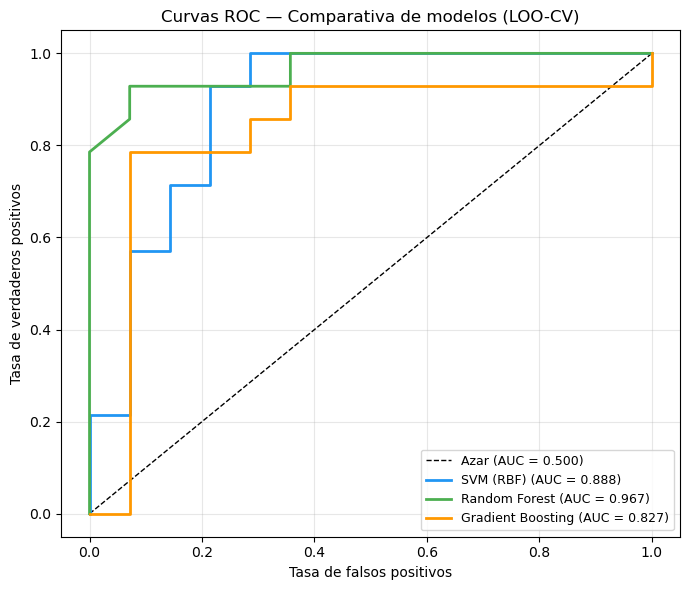

In [23]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

colores = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1], [0,1], 'k--', lw=1, label='Azar (AUC = 0.500)')

for (nombre, vals), color in zip(resultados_comp.items(), colores):
    fpr, tpr, _ = roc_curve(vals['trues'], vals['probas'])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{nombre} (AUC = {vals['AUC']:.3f})")

ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Curvas ROC — Comparativa de modelos (LOO-CV)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_comparativa.png', dpi=150)
plt.show()

La comparativa de modelos muestra que Random Forest es el clasificador con mejor 
rendimiento, alcanzando una accuracy del 89.3% y un AUC de 0.967 bajo validación 
leave-one-out. Esto indica que las variables de presencia digital recogidas permiten predecir con bastante precisión en esta muestra si una cadena de restauración será mencionada por los 
modelos de lenguaje.

El SVM con kernel RBF obtiene también resultados sólidos (accuracy 85.7%, AUC 0.888), 
mientras que Gradient Boosting queda algo por detrás (75.0%, AUC 0.827). Los modelos 
de referencia previos —regresión logística (78.6%) y MLP (75.0%)— quedan superados 
en ambas métricas, lo que confirma que los métodos de ensemble son más adecuados 
para este tipo de datos tabulares con muestra pequeña.

La curva ROC del Random Forest se mantiene muy próxima a la esquina superior izquierda 
desde el inicio, lo que refleja una capacidad discriminativa alta incluso con n=28. 
El perfil escalonado de las curvas es esperable dado el tamaño de la muestra y la 
validación leave-one-out.

In [24]:
!pip install shap -q

/var/folders/h5/nhh63hdj0zq4fpwbcxyxr1lh0000gn/T/ipykernel_70515/319817776.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_pos, X_scaled, feature_names=feature_names,


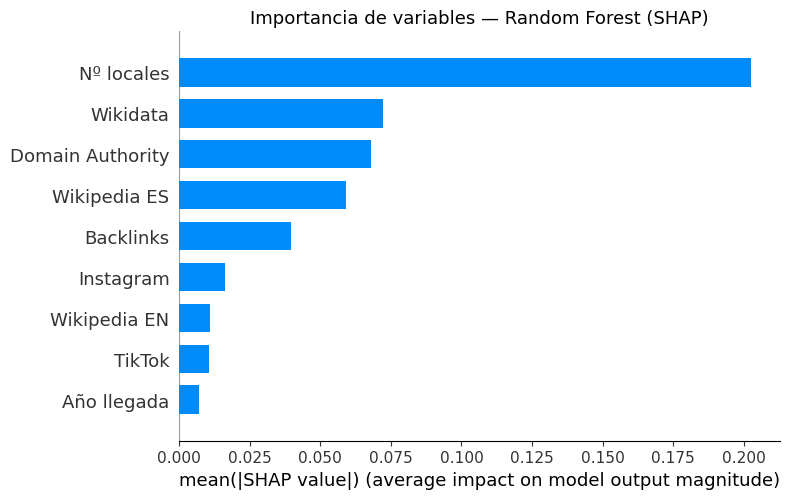

In [25]:
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Redefinir por si se sobreescribió
y = (df_dig['grupo'] == 'A').astype(int).values

# Entrenar Random Forest sobre todos los datos
scaler_shap = StandardScaler()
X_scaled = scaler_shap.fit_transform(X)

rf_full = RandomForestClassifier(n_estimators=100, random_state=42)
rf_full.fit(X_scaled, y)

# Calcular SHAP values
explainer   = shap.TreeExplainer(rf_full)
shap_values = explainer.shap_values(X_scaled)

shap_pos = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values[1]

feature_names = ['Año llegada', 'Nº locales', 'Domain Authority', 'Backlinks',
                 'Instagram', 'TikTok', 'Wikipedia ES', 'Wikipedia EN', 'Wikidata']

shap.summary_plot(shap_pos, X_scaled, feature_names=feature_names,
                  plot_type='bar', show=False)
plt.title('Importancia de variables — Random Forest (SHAP)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_importancia.png', dpi=150)
plt.show()

El análisis SHAP sobre el Random Forest revela que la variable con mayor impacto 
en la predicción es el número de locales en España, con una importancia media muy 
superior al resto de variables. Esto sugiere que la presencia física de una cadena 
—su implantación territorial— es el factor que los modelos de lenguaje reflejan con 
más fidelidad: las cadenas con mayor red de establecimientos son las que 
sistemáticamente aparecen en sus respuestas.

A mayor distancia, Wikidata, Domain Authority y Wikipedia ES aparecen como las 
siguientes variables más relevantes, todas ellas relacionadas con la presencia y 
autoridad en fuentes de conocimiento estructuradoque podrían estar presentes en los datos de entrenamiento de los LLM Los backlinks ocupan el quinto lugar, reforzando la idea de que 
la visibilidad web contribuye, aunque de forma secundaria.

Por el contrario, las redes sociales (Instagram, TikTok) y el año de llegada a 
España tienen un impacto mínimo en el modelo, lo que indica que la popularidad 
en redes o la antigüedad de la marca no son factores determinantes para aparecer 
en las respuestas de los LLMs.

/var/folders/h5/nhh63hdj0zq4fpwbcxyxr1lh0000gn/T/ipykernel_70515/1457293603.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_pos, X_scaled, feature_names=feature_names,


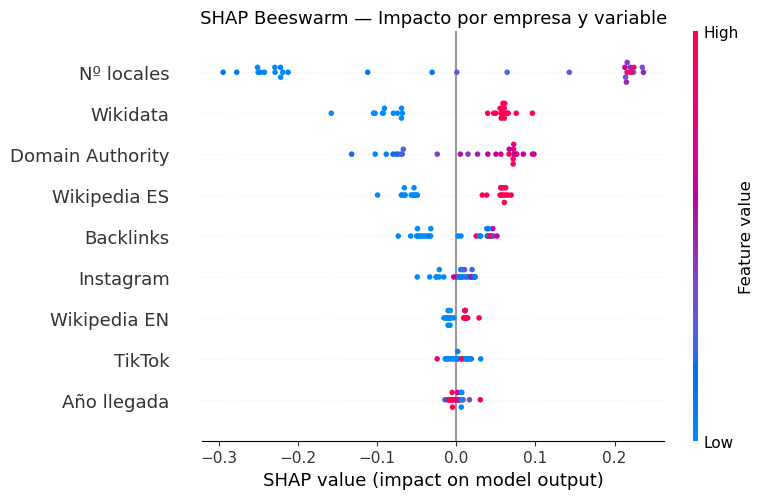

In [26]:
# SHAP Beeswarm — dirección e intensidad del efecto por variable
shap.summary_plot(shap_pos, X_scaled, feature_names=feature_names,
                  plot_type='dot', show=False)
plt.title('SHAP Beeswarm — Impacto por empresa y variable', fontsize=13)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150)
plt.show()

## 5. Tests de Fisher para variables binarias

Además de Wikipedia ES, recogí otras dos variables binarias: Wikipedia EN y Wikidata. Aplico el test exacto de Fisher a las tres para comparar su distribución entre grupos y ver cuáles discriminan mejor.

In [27]:
from scipy.stats import fisher_exact
import pandas as pd

# Datos binarios por empresa
wiki_es =  [1,1,1,1,1,1,1,1,1,1,1,0,1,1, 0,0,0,0,0,0,0,0,1,0,0,0,0,1]
wiki_en =  [1,0,1,0,1,1,1,1,1,1,0,0,1,1, 0,0,0,0,0,0,0,0,1,0,1,0,0,1]
wikidata = [1,1,1,1,1,1,1,1,1,1,1,1,1,1, 0,0,0,0,0,0,0,0,1,0,1,0,0,1]
grupo =    ['A']*14 + ['B']*14

df_bin = pd.DataFrame({'grupo': grupo, 'wiki_es': wiki_es, 'wiki_en': wiki_en, 'wikidata': wikidata})

variables_bin = {'Wikipedia ES': 'wiki_es', 'Wikipedia EN': 'wiki_en', 'Wikidata': 'wikidata'}

print("=== Test exacto de Fisher — Variables binarias ===\n")
print(f"{'Variable':<15} {'A-Sí':>6} {'A-No':>6} {'B-Sí':>6} {'B-No':>6} {'p-valor':>10} {'Significativa':>14}")
print("-" * 72)

for nombre, col in variables_bin.items():
    a_si = df_bin[df_bin['grupo']=='A'][col].sum()
    a_no = 14 - a_si
    b_si = df_bin[df_bin['grupo']=='B'][col].sum()
    b_no = 14 - b_si
    tabla = [[a_si, a_no], [b_si, b_no]]
    _, p = fisher_exact(tabla)
    sig = 'Sí' if p < 0.05 else 'No'
    print(f"{nombre:<15} {a_si:>6} {a_no:>6} {b_si:>6} {b_no:>6} {p:>10.6f} {sig:>14}")

=== Test exacto de Fisher — Variables binarias ===

Variable          A-Sí   A-No   B-Sí   B-No    p-valor  Significativa
------------------------------------------------------------------------
Wikipedia ES        13      1      2     12   0.000069             Sí
Wikipedia EN        10      4      3     11   0.021301             Sí
Wikidata            14      0      3     11   0.000034             Sí


Las tres variables binarias presentan diferencias estadísticamente significativas entre grupos. La más discriminante es Wikidata (p=0.000034): el 100% de las empresas del Grupo A tiene entrada en Wikidata frente a solo 3 del Grupo B. Wikipedia ES también discrimina con fuerza (p=0.000069): 13 de 14 empresas mencionadas por los LLMs tienen artículo en Wikipedia en español, frente a solo 2 del Grupo B. Wikipedia EN, aunque con menor potencia (p=0.021), también resulta significativa.

Estos resultados apuntan a que la presencia en fuentes de conocimiento estructurado —especialmente Wikidata y Wikipedia— es uno de los factores más claramente asociados a la aparición de una empresa en las respuestas de los modelos.

## 6. Mann-Whitney para variables continuas entre grupos

Además de calcular la correlación de Spearman, comparo directamente si los valores de Domain Authority y backlinks son significativamente distintos entre el Grupo A y el Grupo B usando el test de Mann-Whitney U.

In [28]:
from scipy import stats

variables_cont = {
    'Domain Authority': 'domain_authority',
    'Backlinks': 'backlinks',
    'Seguidores Instagram': 'instagram',
    'Seguidores TikTok': 'tiktok'
}

grupo_a = df_vars[df_vars['grupo'] == 'A']
grupo_b = df_vars[df_vars['grupo'] == 'B']

print("=== Mann-Whitney U — Comparativa entre Grupo A y Grupo B ===\n")
print(f"{'Variable':<25} {'Media A':>9} {'Media B':>9} {'U':>8} {'p-valor':>10} {'Significativa':>14}")
print("-" * 80)

for nombre, col in variables_cont.items():
    a_vals = grupo_a[col].values
    b_vals = grupo_b[col].values
    u, p = stats.mannwhitneyu(a_vals, b_vals, alternative='two-sided')
    sig = ' Sí' if p < 0.05 else 'No'
    print(f"{nombre:<25} {a_vals.mean():>9.1f} {b_vals.mean():>9.1f} {u:>8.0f} {p:>10.4f} {sig:>14}")

=== Mann-Whitney U — Comparativa entre Grupo A y Grupo B ===

Variable                    Media A   Media B        U    p-valor  Significativa
--------------------------------------------------------------------------------
Domain Authority               47.2      34.9      179     0.0002             Sí
Backlinks                   54039.8   37702.9      165     0.0022             Sí
Seguidores Instagram       351978.6  118162.7      142     0.0456             Sí
Seguidores TikTok          488982.0   69847.1      142     0.0482             Sí


El Grupo A presenta valores medios superiores en las cuatro variables analizadas. Las diferencias son estadísticamente significativas en todos los casos: Domain Authority (Media A=47.2 vs Media B=34.9, p=0.0002), Backlinks (p=0.0022), Seguidores Instagram (p=0.046) y Seguidores TikTok (p=0.048).

Las variables de autoridad web (DA y backlinks) muestran mayor separación entre grupos que las de redes sociales, lo que es coherente con los resultados de las correlaciones de Spearman.

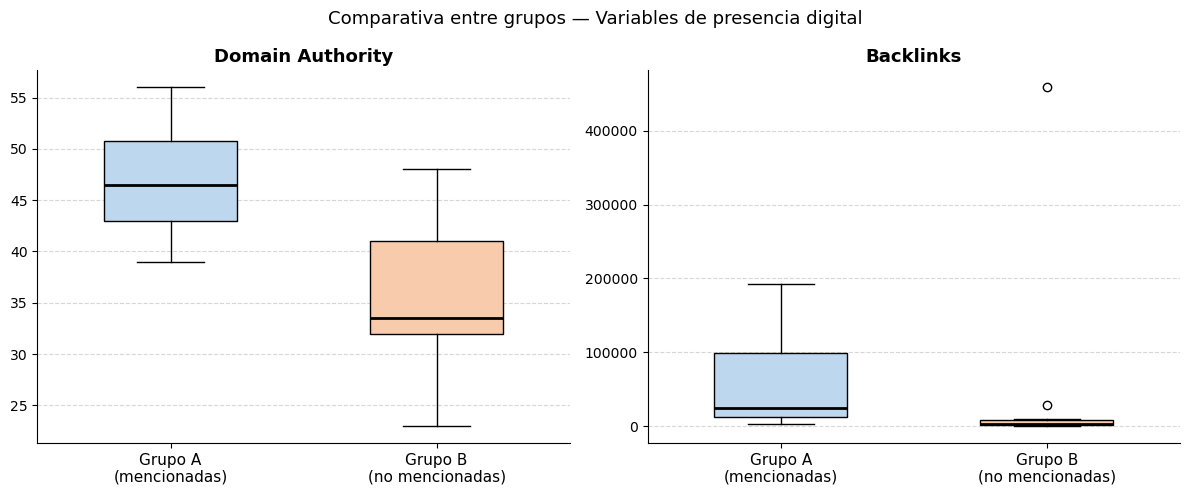

Boxplot guardado.


In [29]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (nombre, col) in zip(axes, [('Domain Authority', 'domain_authority'), ('Backlinks', 'backlinks')]):
    data_a = df_vars[df_vars['grupo'] == 'A'][col].values
    data_b = df_vars[df_vars['grupo'] == 'B'][col].values
    bp = ax.boxplot([data_a, data_b], patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#BDD7EE')
    bp['boxes'][1].set_facecolor('#F8CBAD')
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Grupo A\n(mencionadas)', 'Grupo B\n(no mencionadas)'], fontsize=11)
    ax.set_title(nombre, fontsize=13, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.suptitle('Comparativa entre grupos — Variables de presencia digital', fontsize=13)
plt.tight_layout()
plt.savefig('boxplot_grupos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Boxplot guardado.")

El boxplot confirma visualmente lo que ya apuntaban los resultados del Mann-Whitney. 
En el Domain Authority la separación entre grupos es clara: el Grupo A se concentra 
en valores altos (mediana ≈ 47) mientras que el Grupo B presenta valores más bajos y 
dispersos (mediana ≈ 34). En backlinks la diferencia existe pero hay más variabilidad 
dentro del Grupo A, con algún valor atípico que amplía el rango — lo que era de esperar 
en una variable tan heterogénea como el número de enlaces entrantes.

En conjunto, la visualización refuerza que las empresas mencionadas por los modelos 
no solo tienen más autoridad web de media, sino que además son más homogéneas entre sí 
en ese sentido.

In [30]:
from scipy import stats
import numpy as np

# Datos por grupo
locales_A = [400, 60, 150, 400, 50, 107, 63, 140, 900, 440, 101, 116, 50, 31]
locales_B = [75, 75, 13, 50, 30, 20, 75, 44, 362, 4, 10, 5, 10, 40]

año_A = [1993, 2013, 1994, 1987, 2014, 1969, 1971, 1939, 1991, 1960, 1981, 1979, 1972, 1962]
año_B = [2007, 2000, 2014, 1991, 1999, 2021, 2000, 2016, 1958, 2019, 2006, 2000, 2011, 1984]

for nombre, a, b in [('Nº locales', locales_A, locales_B), ('Año llegada', año_A, año_B)]:
    rho, p_sp = stats.spearmanr(a + b, [1]*14 + [0]*14)
    u, p_mw   = stats.mannwhitneyu(a, b, alternative='two-sided')
    print(f"{nombre}")
    print(f"  Spearman ρ = {rho:.4f}  p = {p_sp:.4f}")
    print(f"  Mann-Whitney U = {u:.1f}  p = {p_mw:.4f}\n")

Nº locales
  Spearman ρ = 0.6110  p = 0.0006
  Mann-Whitney U = 167.0  p = 0.0016

Año llegada
  Spearman ρ = -0.5310  p = 0.0036
  Mann-Whitney U = 38.0  p = 0.0062



## 7. Estadísticos descriptivos por grupo

Se calculan los principales estadísticos —media, desviación típica, mínimo, máximo y 
mediana— para las variables continuas del estudio, desglosados por grupo. Esto permite 
caracterizar cuantitativamente las diferencias entre las empresas mencionadas por los 
modelos y las que no recibieron ninguna mención.

In [31]:
print("=== ESTADÍSTICOS DESCRIPTIVOS POR GRUPO ===\n")
desc = df_vars.groupby('grupo')[['domain_authority','backlinks','instagram','tiktok']].agg(
    ['mean','median','std','min','max']).round(2)
print(desc)

=== ESTADÍSTICOS DESCRIPTIVOS POR GRUPO ===

      domain_authority                      backlinks                      \
                  mean median   std min max      mean   median        std   
grupo                                                                       
A                47.21   46.5  5.32  39  56  54039.79  25068.5   58504.28   
B                34.86   33.5  7.13  23  48  37702.93   2899.5  121523.68   

                     instagram                                       \
        min     max       mean    median        std    min      max   
grupo                                                                 
A      2594  192348  351978.57  128000.0  523421.75  15300  1800000   
B       152  459188  118162.71   44900.0  178706.24   3836   647000   

          tiktok                                      
            mean   median         std   min      max  
grupo                                                 
A      488982.00  40350.0  1455720.63  3000  550

Los estadísticos descriptivos confirman las diferencias observadas en los análisis 
anteriores. El Grupo A presenta medias superiores en las cuatro variables: Domain 
Authority (47.2 vs. 34.9), backlinks (54.040 vs. 37.703), seguidores en Instagram 
(351.979 vs. 118.163) y seguidores en TikTok (488.982 vs. 69.847).

Cabe destacar la elevada desviación típica en las variables de redes sociales y 
backlinks dentro del Grupo A, lo que indica que hay empresas muy por encima de la 
media del grupo — como KFC en TikTok o Telepizza en backlinks — que elevan 
considerablemente los valores medios. La mediana es en estos casos más representativa 
que la media para describir el grupo en su conjunto.

## 8. Análisis de posición y orden de aparición

En este apartado se analiza no solo cuántas veces aparece cada empresa en las respuestas, sino en qué posición relativa lo hace. La posición se define como el orden de primera mención dentro de cada respuesta: la primera empresa que aparece recibe la posición 1, la segunda la 2, y así sucesivamente. Se calcula la posición media de cada empresa del Grupo A a lo largo de todas las consultas en las que es mencionada, y se examina si existe correlación entre la frecuencia total de menciones y dicha posición media mediante la correlación de Spearman.

In [32]:
import re
import numpy as np
import pandas as pd

# Alias de búsqueda por empresa
aliases = {
    '100 Montaditos':     ['100 Montaditos', 'Montaditos'],
    'VIPS':               ['VIPS'],
    "Foster's Hollywood": ["Foster's Hollywood", "Foster's", "Fosters Hollywood"],
    'La Tagliatella':     ['La Tagliatella', 'Tagliatella'],
    'Ginos':              ['Ginos'],
    'Telepizza':          ['Telepizza'],
    'The Good Burger':    ['The Good Burger', 'Good Burger'],
    'KFC':                ['KFC', 'Kentucky Fried Chicken'],
    'Goiko':              ['Goiko'],
    "Domino's Pizza":     ["Domino's Pizza", "Domino's", "Dominos"],
    'Rodilla':            ['Rodilla'],
    'Lizarran':           ['Lizarran'],
    'Popeyes':            ['Popeyes'],
    'Taco Bell':          ['Taco Bell'],
}

def extraer_posiciones(texto, aliases):
    """
    Divide el texto en respuestas individuales (C1-C5) y calcula, para cada empresa,
    su posición de aparición (orden de primera mención) dentro de cada respuesta.
    """
    partes = re.split(r'(?i)(?=consulta\s*\d|c\d[\s\.\:])', texto)
    partes = [p.strip() for p in partes if len(p.strip()) > 50]
    if len(partes) < 2:
        partes = [texto]

    posiciones = {emp: [] for emp in aliases}

    for resp in partes:
        resp_lower = resp.lower()
        primer_char = {}
        for emp, alias_list in aliases.items():
            pos = None
            for alias in alias_list:
                idx = resp_lower.find(alias.lower())
                if idx != -1 and (pos is None or idx < pos):
                    pos = idx
            primer_char[emp] = pos

        aparecen = [(emp, p) for emp, p in primer_char.items() if p is not None]
        aparecen.sort(key=lambda x: x[1])
        orden = {emp: i + 1 for i, (emp, _) in enumerate(aparecen)}

        for emp in aliases:
            posiciones[emp].append(orden.get(emp, np.nan))

    return posiciones

# Aplicar a ambos modelos (texto_gpt y texto_gemini cargados en sección 10.3)
pos_gpt    = extraer_posiciones(texto_gpt,    aliases)
pos_gemini = extraer_posiciones(texto_gemini, aliases)
print("Posiciones extraídas correctamente.")

Posiciones extraídas correctamente.


In [33]:
# Tabla resumen: empresa, frecuencia total, posición media combinada
filas = []
for emp in aliases:
    freq_total = freq_por_modelo[emp]['gpt'] + freq_por_modelo[emp]['gemini']
    todas_pos  = [p for p in pos_gpt[emp] + pos_gemini[emp] if not np.isnan(p)]
    pos_media  = round(np.mean(todas_pos), 2) if todas_pos else np.nan
    filas.append({'empresa': emp, 'frecuencia': freq_total, 'posicion_media': pos_media})

df_pos = pd.DataFrame(filas).dropna(subset=['posicion_media']).sort_values('posicion_media')
print("=== POSICIÓN MEDIA POR EMPRESA (orden de aparición) ===\n")
print(df_pos.to_string(index=False))

=== POSICIÓN MEDIA POR EMPRESA (orden de aparición) ===

           empresa  frecuencia  posicion_media
    100 Montaditos           8            3.00
           Rodilla           3            3.33
         Telepizza           6            3.50
              VIPS           8            4.12
               KFC           5            4.20
Foster's Hollywood           8            4.50
   The Good Burger           6            5.00
             Goiko           5            5.20
    La Tagliatella           7            5.71
             Ginos           7            5.71
    Domino's Pizza           5            7.00
           Popeyes           2            7.00
          Lizarran           3            9.00
         Taco Bell           2            9.50


In [34]:
# Correlación de Spearman: frecuencia total vs. posición media (implementación manual)
def spearman_manual(x, y):
    n = len(x)
    def rankdata(a):
        orden = sorted(range(n), key=lambda i: a[i])
        rangos = [0] * n
        i = 0
        while i < n:
            j = i
            while j < n - 1 and a[orden[j+1]] == a[orden[j]]:
                j += 1
            rango_medio = (i + j) / 2 + 1
            for k in range(i, j+1):
                rangos[orden[k]] = rango_medio
            i = j + 1
        return rangos
    rx = rankdata(x)
    ry = rankdata(y)
    mean_rx = sum(rx) / n
    mean_ry = sum(ry) / n
    num   = sum((rx[i] - mean_rx) * (ry[i] - mean_ry) for i in range(n))
    den_x = sum((rx[i] - mean_rx)**2 for i in range(n)) ** 0.5
    den_y = sum((ry[i] - mean_ry)**2 for i in range(n)) ** 0.5
    return num / (den_x * den_y) if den_x * den_y != 0 else 0

x   = df_pos['frecuencia'].tolist()
y   = df_pos['posicion_media'].tolist()
rho = spearman_manual(x, y)
print(f"Correlación de Spearman (frecuencia vs. posición media): ρ = {rho:.3f}")
print("→ Correlación negativa: las empresas más frecuentes tienden a aparecer antes.")

Correlación de Spearman (frecuencia vs. posición media): ρ = -0.546
→ Correlación negativa: las empresas más frecuentes tienden a aparecer antes.


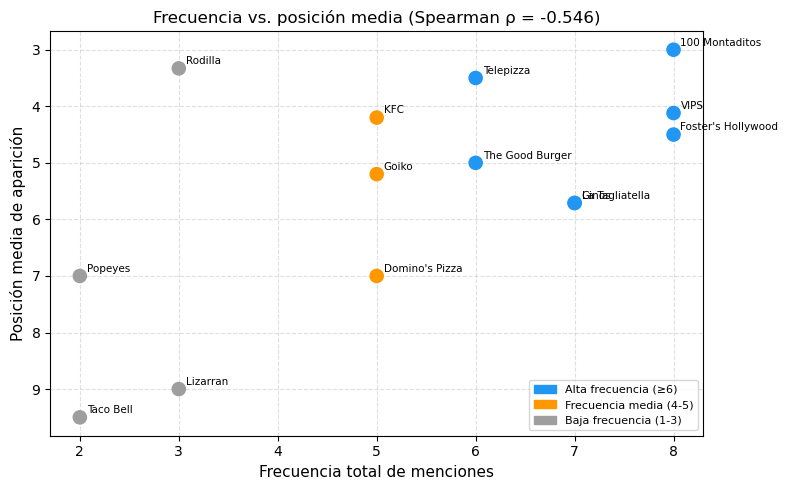

Gráfico guardado.


In [35]:
fig, ax = plt.subplots(figsize=(8, 5))
colores = ['#2196F3' if f >= 6 else '#FF9800' if f >= 4 else '#9E9E9E'
           for f in df_pos['frecuencia']]

ax.scatter(df_pos['frecuencia'], df_pos['posicion_media'], c=colores, s=90, zorder=3)

for _, row in df_pos.iterrows():
    ax.annotate(row['empresa'],
                xy=(row['frecuencia'], row['posicion_media']),
                xytext=(5, 3), textcoords='offset points', fontsize=7.5)

ax.set_xlabel('Frecuencia total de menciones', fontsize=11)
ax.set_ylabel('Posición media de aparición', fontsize=11)
ax.set_title(f'Frecuencia vs. posición media (Spearman ρ = -0.546)', fontsize=12)
ax.invert_yaxis()
ax.grid(True, linestyle='--', alpha=0.4)

legend_elements = [
    mpatches.Patch(color='#2196F3', label='Alta frecuencia (≥6)'),
    mpatches.Patch(color='#FF9800', label='Frecuencia media (4-5)'),
    mpatches.Patch(color='#9E9E9E', label='Baja frecuencia (1-3)'),
]
ax.legend(handles=legend_elements, fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('posicion_vs_frecuencia.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado.")

El análisis muestra una correlación de Spearman negativa (ρ = −0.546) entre la frecuencia 
de mención y la posición media de aparición. Las empresas más citadas tienden a aparecer 
antes dentro de cada respuesta, lo que sugiere que los modelos no solo mencionan más a 
las cadenas con mayor presencia digital sino que además las sitúan en posiciones 
destacadas dentro del texto.

Telepizza, 100 Montaditos, VIPS o Foster's Hollywood —todas con 6 u 8 menciones— 
aparecen sistemáticamente entre las primeras posiciones. En el extremo opuesto, 
Lizarran, Taco Bell o Popeyes no solo reciben menos menciones sino que cuando aparecen 
lo hacen tarde, lo que reduce aún más su visibilidad efectiva en las respuestas generadas.

Una excepción notable es Rodilla, que con solo 3 menciones consigue una posición media 
relativamente alta (3.67), lo que sugiere que cuando los modelos la incluyen tienden a 
hacerlo de forma prominente.

## 9. Comparativa ChatGPT vs Gemini

Una vez analizados los resultados de forma conjunta, se examina si existen diferencias 
entre los dos modelos en cuanto a qué empresas mencionan, con qué frecuencia y en qué 
posición. Esta comparativa permite identificar si ambos modelos siguen patrones similares 
o si cada uno tiene sesgos propios a la hora de recomendar cadenas de restauración.

In [36]:
print("=== FRECUENCIAS POR MODELO ===\n")
print(f"{'Empresa':<25} {'GPT':>6} {'Gemini':>8} {'Total':>7} {'Solo GPT':>10} {'Solo Gemini':>12}")
print("-" * 72)

for emp, freqs in sorted(freq_por_modelo.items(), 
                          key=lambda x: x[1]['gpt']+x[1]['gemini'], reverse=True):
    gpt    = freqs['gpt']
    gemini = freqs['gemini']
    total  = gpt + gemini
    if total == 0:
        continue
    solo_gpt    = '✓' if gpt > 0 and gemini == 0 else ''
    solo_gemini = '✓' if gemini > 0 and gpt == 0 else ''
    print(f"{emp:<25} {gpt:>6} {gemini:>8} {total:>7} {solo_gpt:>10} {solo_gemini:>12}")

print(f"\nTotal menciones GPT:    {sum(v['gpt'] for v in freq_por_modelo.values())}")
print(f"Total menciones Gemini: {sum(v['gemini'] for v in freq_por_modelo.values())}")
print(f"Empresas solo en GPT:   {sum(1 for v in freq_por_modelo.values() if v['gpt']>0 and v['gemini']==0)}")
print(f"Empresas solo en Gemini:{sum(1 for v in freq_por_modelo.values() if v['gemini']>0 and v['gpt']==0)}")
print(f"Empresas en ambos:      {sum(1 for v in freq_por_modelo.values() if v['gpt']>0 and v['gemini']>0)}")

=== FRECUENCIAS POR MODELO ===

Empresa                      GPT   Gemini   Total   Solo GPT  Solo Gemini
------------------------------------------------------------------------
100 Montaditos                 4        4       8                        
VIPS                           3        5       8                        
Foster's Hollywood             4        4       8                        
La Tagliatella                 3        4       7                        
Ginos                          3        4       7                        
Telepizza                      4        2       6                        
The Good Burger                3        3       6                        
KFC                            4        1       5                        
Goiko                          1        4       5                        
Domino's Pizza                 2        3       5                        
Rodilla                        1        2       3                        
Lizarra

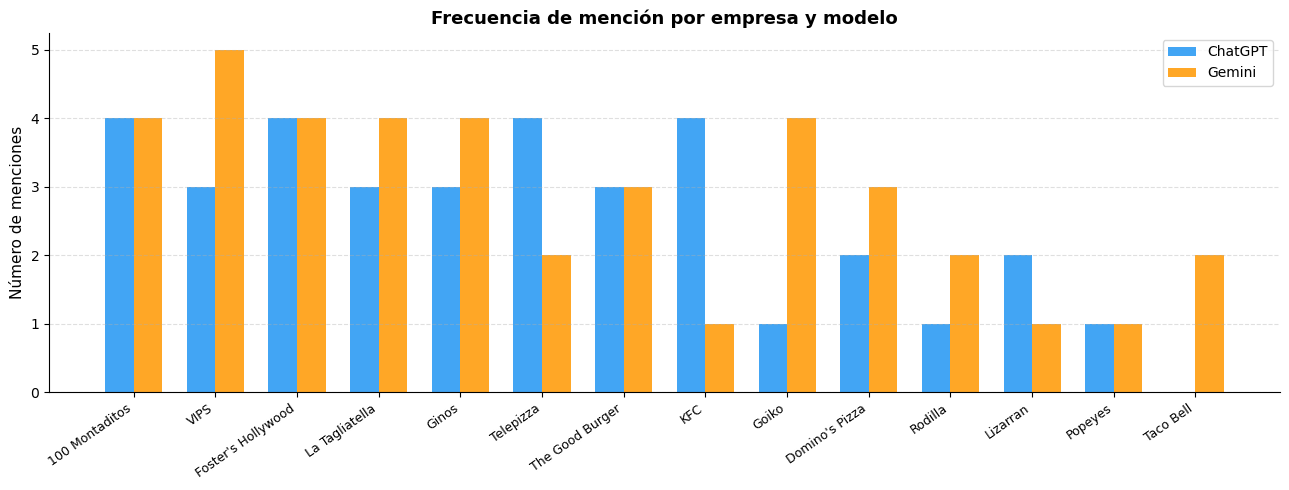

Gráfico guardado.


In [37]:
import matplotlib.pyplot as plt
import numpy as np

empresas_a = [e for e, v in freq_por_modelo.items() if v['gpt']+v['gemini'] > 0]
gpt_vals    = [freq_por_modelo[e]['gpt']    for e in empresas_a]
gemini_vals = [freq_por_modelo[e]['gemini'] for e in empresas_a]

# Ordenar por frecuencia total
orden = sorted(range(len(empresas_a)), key=lambda i: gpt_vals[i]+gemini_vals[i], reverse=True)
empresas_a  = [empresas_a[i]  for i in orden]
gpt_vals    = [gpt_vals[i]    for i in orden]
gemini_vals = [gemini_vals[i] for i in orden]

x = np.arange(len(empresas_a))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width/2, gpt_vals,    width, label='ChatGPT', color='#2196F3', alpha=0.85)
ax.bar(x + width/2, gemini_vals, width, label='Gemini',  color='#FF9800', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(empresas_a, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Número de menciones', fontsize=11)
ax.set_title('Frecuencia de mención por empresa y modelo', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('comparativa_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado.")

Los resultados muestran que ambos modelos son bastante consistentes en cuanto a qué 
empresas mencionan: 13 de las 14 cadenas del Grupo A aparecen en los dos modelos, 
y solo Taco Bell es mencionada exclusivamente por Gemini. Sin embargo, sí existen 
diferencias en la intensidad con la que cada modelo cita a cada empresa.

Gemini genera más menciones en total (40 vs. 35 de ChatGPT) y tiende a distribuirlas 
de forma más uniforme entre las empresas. ChatGPT en cambio concentra más sus menciones 
en cadenas muy consolidadas como KFC, Telepizza o Foster's Hollywood, que obtienen su 
máximo en este modelo. Casos como Goiko o VIPS ilustran el patrón contrario: Gemini las 
cita con mucha más frecuencia que ChatGPT.

Estas diferencias sugieren que, aunque ambos modelos comparten un núcleo común de 
empresas reconocidas, cada uno tiene ciertos sesgos propios que podrían estar relacionados 
con los datos con los que fueron entrenados o con la forma en que ponderan la relevancia 
de cada cadena.

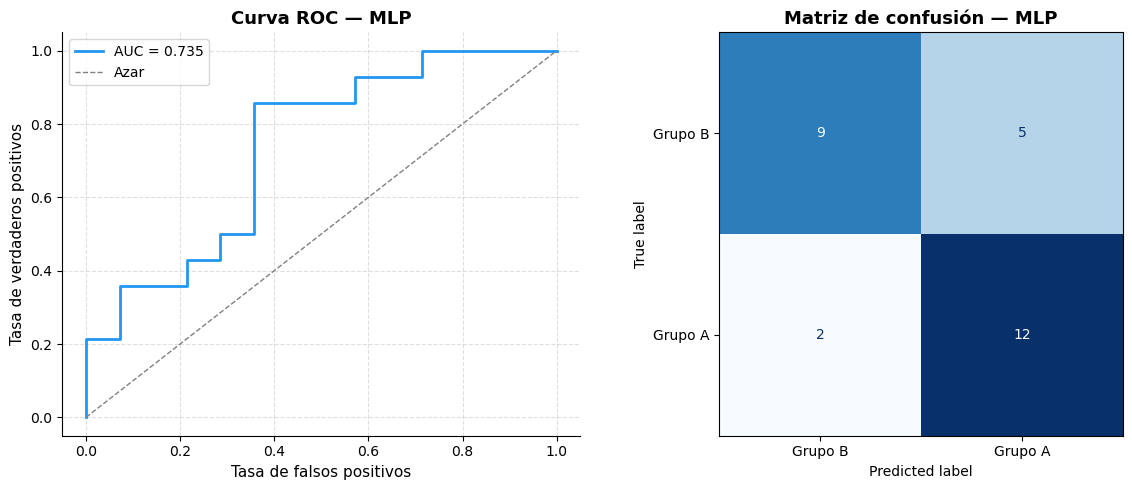

AUC-ROC: 0.7347


In [38]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Curva ROC ────────────────────────────────────────────────────────────────
axes[0].plot(fpr, tpr, color='#2196F3', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Azar')
axes[0].set_xlabel('Tasa de falsos positivos', fontsize=11)
axes[0].set_ylabel('Tasa de verdaderos positivos', fontsize=11)
axes[0].set_title('Curva ROC — MLP', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.4)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Matriz de confusión ───────────────────────────────────────────────────────
cm = confusion_matrix(y_true_all, y_pred_all)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Grupo B', 'Grupo A'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de confusión — MLP', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('roc_confusion_mlp.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"AUC-ROC: {roc_auc:.4f}")

La curva ROC del MLP obtiene un AUC de 0,735, lo que indica una capacidad discriminativa 
moderada-alta, muy por encima del azar (AUC = 0.5). La curva muestra un perfil escalonado 
típico de muestras pequeñas, donde cada punto corresponde a una de las 28 empresas del 
conjunto de validación.

La matriz de confusión detalla los errores del modelo: de las 14 empresas del Grupo B, 
9 se clasifican correctamente y 5 se predicen erróneamente como Grupo A. De las 14 del 
Grupo A, 12 se clasifican correctamente y solo 2 se predicen como Grupo B. El modelo 
tiene por tanto más dificultad para identificar las empresas no mencionadas que las 
mencionadas, lo que es coherente con el desbalance de información disponible — las 
empresas del Grupo A tienen más presencia digital y sus patrones son más fáciles de 
aprender.

## 11. Visualización t-SNE — Embeddings + variables digitales

Para visualizar la distribución de las empresas en un espacio bidimensional, 
se aplica t-SNE sobre la concatenación de los embeddings semánticos web 
(768 dimensiones, Sentence-BERT) y las variables digitales normalizadas 
(9 variables). Este input conjunto es el mismo que se usa en los modelos 
predictivos, lo que permite interpretar la visualización en coherencia con 
los resultados de clasificación.

Shape input concatenado: (28, 777)


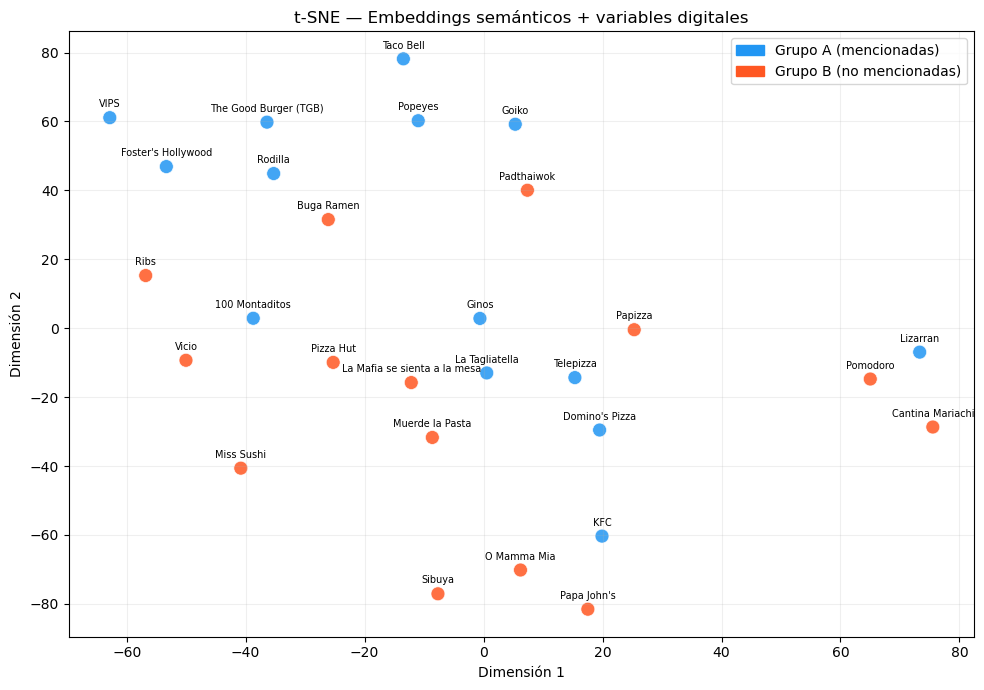

In [39]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Concatenar embeddings web + variables digitales normalizadas
scaler_tsne = StandardScaler()
X_dig_scaled = scaler_tsne.fit_transform(X)
X_concat = np.concatenate([embeddings_all, X_dig_scaled], axis=1)
print(f"Shape input concatenado: {X_concat.shape}")

# Normalizar el input conjunto antes del t-SNE
scaler_concat = StandardScaler()
X_concat_scaled = scaler_concat.fit_transform(X_concat)

# t-SNE
tsne = TSNE(n_components=2, perplexity=5, random_state=42,
            method='exact', max_iter=1000)
X_2d = tsne.fit_transform(X_concat_scaled)

# Visualización
grupos_tsne = df_dig['grupo'].tolist()
colores = ['#2196F3' if g == 'A' else '#FF5722' for g in grupos_tsne]

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=colores, s=100,
           alpha=0.85, edgecolors='white', linewidths=0.5)

for i, nombre in enumerate(df_dig['empresa']):
    ax.annotate(nombre, (X_2d[i, 0], X_2d[i, 1]),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 6), textcoords='offset points')

patch_a = mpatches.Patch(color='#2196F3', label='Grupo A (mencionadas)')
patch_b = mpatches.Patch(color='#FF5722', label='Grupo B (no mencionadas)')
ax.legend(handles=[patch_a, patch_b], loc='upper right')
ax.set_title('t-SNE — Embeddings semánticos + variables digitales')
ax.set_xlabel('Dimensión 1')
ax.set_ylabel('Dimensión 2')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('tsne_concatenado.png', dpi=150)
plt.show()

La visualización t-SNE sobre el espacio conjunto de embeddings semánticos y 
variables digitales muestra una distribución sin separación limpia entre grupos, 
lo que es coherente con los resultados estadísticos previos. No existe una frontera 
clara que divida las empresas mencionadas de las no mencionadas en este espacio 
combinado, lo que indica que la distinción entre grupos no responde a un único 
patrón latente simple.

Aun así, se observa cierta tendencia: algunas empresas del Grupo A con alta 
presencia digital (como KFC, Domino's Pizza o Telepizza) se sitúan en zonas 
distintas a cadenas del Grupo B con menor visibilidad online. La dispersión 
general refleja la heterogeneidad interna de ambos grupos y el tamaño reducido 
de la muestra, que limita la capacidad del t-SNE para revelar estructuras 
más definidas.

## 12. Análisis de menciones por consulta (C1–C5)

Extraemos las menciones de cada empresa en cada consulta para analizar la consistencia de los LLMs a lo largo de las cinco preguntas.

In [40]:
import pdfplumber
import re
import pandas as pd

pdf_chatgpt = "consultas/GPT.pdf"
pdf_gemini  = "consultas/GEMINI.pdf"

empresas = df_mod['empresa'].tolist()

def extraer_menciones_por_consulta(pdf_path, modelo):
    texto_total = ""
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            texto_total += (page.extract_text() or "") + "\n"
    
    partes = re.split(r'C(\d)\s+Consulta:', texto_total)
    consultas = {}
    for i in range(1, len(partes)-1, 2):
        consultas[f'C{partes[i]}'] = partes[i+1].lower()
    
    resultados = []
    for clave, contenido in consultas.items():
        for empresa in empresas:
            patron = r'(?<![a-záéíóúüñ])' + re.escape(empresa.lower()) + r'(?![a-záéíóúüñ])'
            mencionada = 1 if re.search(patron, contenido) else 0
            resultados.append({
                'modelo': modelo,
                'consulta': clave,
                'empresa': empresa,
                'mencionada': mencionada
            })
    return resultados

datos  = extraer_menciones_por_consulta(pdf_chatgpt, 'ChatGPT')
datos += extraer_menciones_por_consulta(pdf_gemini,  'Gemini')

df_menciones = pd.DataFrame(datos)

tabla = df_menciones.groupby(['empresa','consulta'])['mencionada'].sum().unstack(fill_value=0)
tabla['TOTAL'] = tabla.sum(axis=1)
tabla = tabla.sort_values('TOTAL', ascending=False)

print(tabla)

consulta                      C1  C2  C3  C4  C5  TOTAL
empresa                                                
VIPS                           2   1   2   2   1      8
Foster's Hollywood             2   1   2   2   1      8
100 Montaditos                 2   1   2   0   2      7
La Tagliatella                 2   0   2   2   1      7
Ginos                          2   0   2   2   1      7
Telepizza                      1   0   2   1   2      6
The Good Burger                1   1   2   1   1      6
KFC                            2   0   0   1   2      5
Goiko                          1   0   1   2   1      5
Lizarran                       1   0   2   0   0      3
Domino's Pizza                 0   0   1   1   1      3
Rodilla                        0   0   2   0   1      3
Popeyes                        2   0   1   0   0      3
Taco Bell                      1   0   0   0   1      2
Pomodoro                       0   0   0   0   0      0
Sibuya                         0   0   0   0   0

In [41]:
df_gpt = df_menciones[df_menciones['modelo'] == 'ChatGPT'].pivot(index='empresa', columns='consulta', values='mencionada')
df_gem = df_menciones[df_menciones['modelo'] == 'Gemini'].pivot(index='empresa', columns='consulta', values='mencionada')

consist_gpt = (df_gpt > 0).sum(axis=1)
consist_gem = (df_gem > 0).sum(axis=1)

df_consist = pd.DataFrame({
    'ChatGPT (de 5)': consist_gpt,
    'Gemini (de 5)': consist_gem
})
df_consist['Ambos'] = df_consist.sum(axis=1)
df_consist = df_consist.sort_values('Ambos', ascending=False)

print(df_consist[df_consist['Ambos'] > 0])

                    ChatGPT (de 5)  Gemini (de 5)  Ambos
empresa                                                 
VIPS                             3              5      8
Foster's Hollywood               4              4      8
100 Montaditos                   3              4      7
La Tagliatella                   3              4      7
Ginos                            3              4      7
Telepizza                        4              2      6
The Good Burger                  3              3      6
KFC                              3              2      5
Goiko                            1              4      5
Lizarran                         2              1      3
Domino's Pizza                   2              1      3
Rodilla                          1              2      3
Popeyes                          1              2      3
Taco Bell                        0              2      2


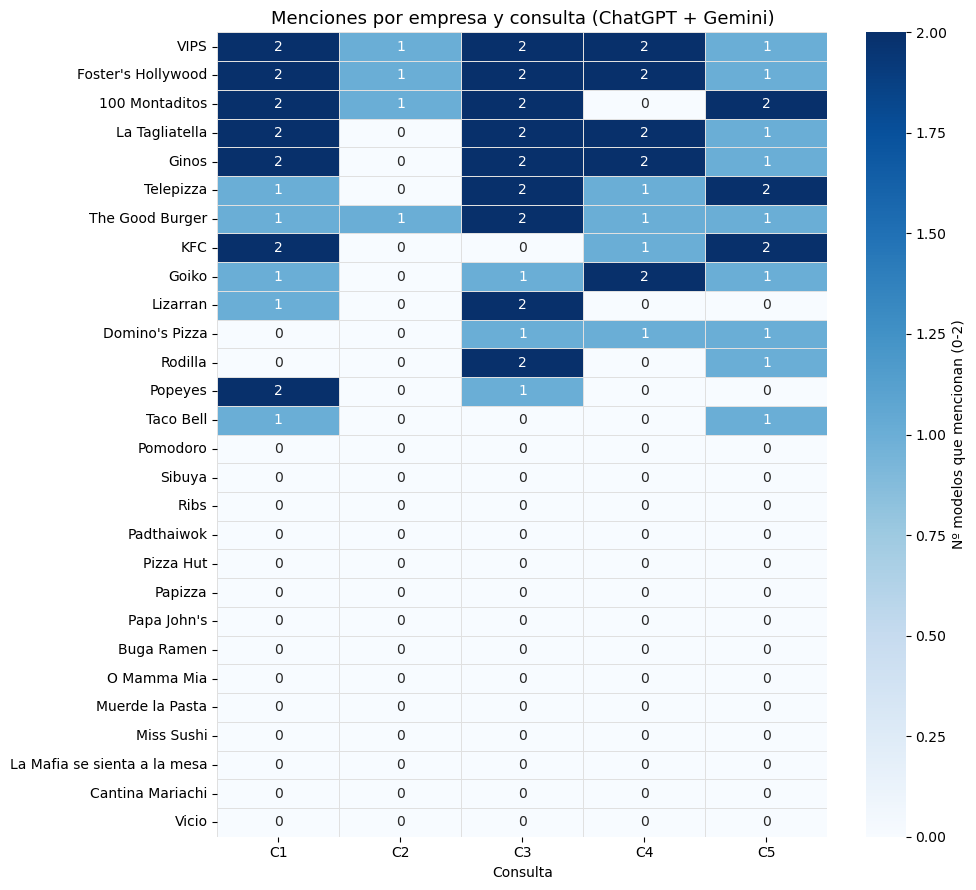

In [42]:
import seaborn as sns

tabla_viz = tabla.drop(columns='TOTAL')
plt.figure(figsize=(10, 9))
sns.heatmap(tabla_viz, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='#e0e0e0',
            cbar_kws={'label': 'Nº modelos que mencionan (0-2)'})
plt.title('Menciones por empresa y consulta (ChatGPT + Gemini)', fontsize=13)
plt.xlabel('Consulta')
plt.ylabel('')
plt.tight_layout()
plt.savefig('heatmap_menciones.png', dpi=150, bbox_inches='tight')
plt.show()

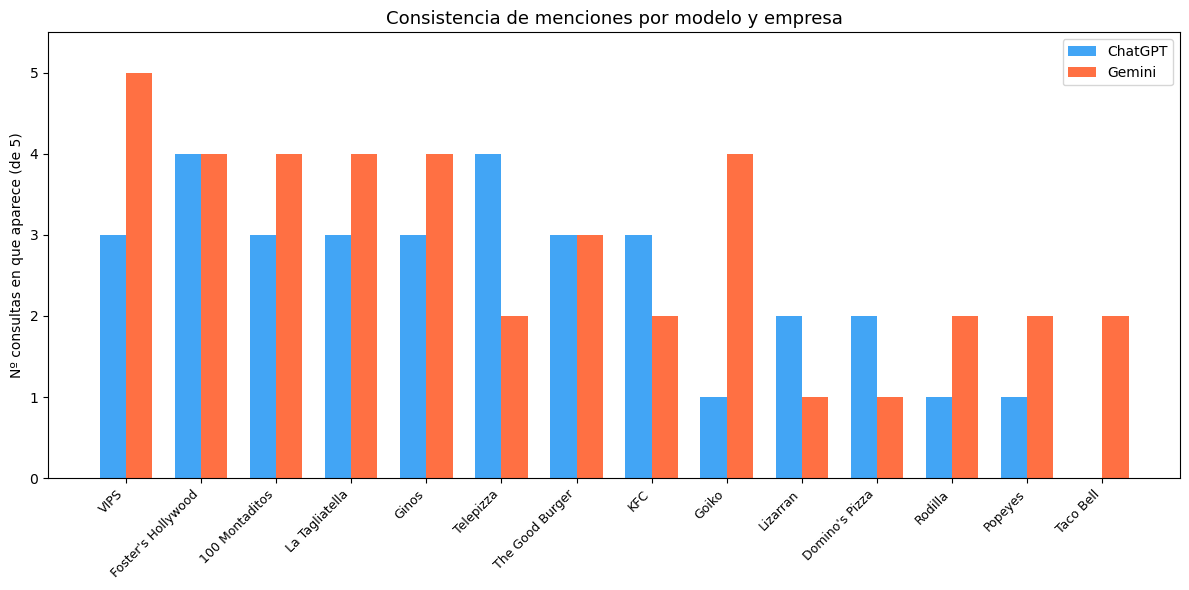

In [43]:
empresas_mencionadas = df_consist[df_consist['Ambos'] > 0].index
x = range(len(empresas_mencionadas))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar([i - width/2 for i in x], df_consist.loc[empresas_mencionadas, 'ChatGPT (de 5)'],
       width, label='ChatGPT', color='#42A5F5')
ax.bar([i + width/2 for i in x], df_consist.loc[empresas_mencionadas, 'Gemini (de 5)'],
       width, label='Gemini', color='#FF7043')

ax.set_xticks(list(x))
ax.set_xticklabels(empresas_mencionadas, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Nº consultas en que aparece (de 5)')
ax.set_title('Consistencia de menciones por modelo y empresa', fontsize=13)
ax.set_ylim(0, 5.5)
ax.yaxis.set_major_locator(plt.MultipleLocator(1))
ax.legend()
plt.tight_layout()
plt.savefig('consistencia_por_modelo.png', dpi=150, bbox_inches='tight')
plt.show()

In [44]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Clasificación por origen cultural de la cocina
origen_cultural = {
    # Española
    '100 Montaditos':            'Española',
    'Goiko':                     'Española',
    'Telepizza':                 'Española',
    'The Good Burger (TGB)':     'Española',
    'VIPS':                      'Española',
    "Foster's Hollywood":        'Española',
    'Rodilla':                   'Española',
    'Lizarran':                  'Española',
    'Vicio':                     'Española',
    'Ribs':                      'Española',
    # Americana
    'KFC':                       'Americana',
    'Domino\'s Pizza':           'Americana',
    'Popeyes':                   'Americana',
    'Taco Bell':                 'Americana',
    'Pizza Hut':                 'Americana',
    "Papa John's":               'Americana',
    # Italiana/Mediterránea
    'La Tagliatella':            'Italiana/Mediterránea',
    'Ginos':                     'Italiana/Mediterránea',
    'Muerde la Pasta':           'Italiana/Mediterránea',
    'La Mafia se sienta a la mesa': 'Italiana/Mediterránea',
    'Papizza':                   'Italiana/Mediterránea',
    'Pomodoro':                  'Italiana/Mediterránea',
    'O Mamma Mia':               'Italiana/Mediterránea',
    # Asiática
    'Miss Sushi':                'Asiática',
    'Sibuya':                    'Asiática',
    'Buga Ramen':                'Asiática',
    'Padthaiwok':                'Asiática',
    # Mexicana
    'Cantina Mariachi':          'Mexicana',
}

df_dig['origen'] = df_dig['empresa'].map(origen_cultural)
df_dig['mencionada'] = (df_dig['grupo'] == 'A').astype(int)

# Resumen por origen
resumen = df_dig.groupby('origen').agg(
    total=('empresa', 'count'),
    mencionadas=('mencionada', 'sum')
).reset_index()
resumen['no_mencionadas'] = resumen['total'] - resumen['mencionadas']
resumen['% mencionadas'] = (resumen['mencionadas'] / resumen['total'] * 100).round(1)
print(resumen.to_string(index=False))

               origen  total  mencionadas  no_mencionadas  % mencionadas
            Americana      6            4               2           66.7
             Asiática      4            0               4            0.0
             Española     10            8               2           80.0
Italiana/Mediterránea      7            2               5           28.6
             Mexicana      1            0               1            0.0


In [45]:
# Fisher exact test: asiática vs resto
asian     = df_dig['origen'] == 'Asiática'
menciones = df_dig['mencionada']

tabla_fisher = pd.crosstab(asian, menciones)
print("Tabla de contingencia (Asiática vs Resto):")
print(tabla_fisher)

odds, p = fisher_exact(tabla_fisher, alternative='less')
print(f"\nFisher exact test (asiática menos mencionada que el resto):")
print(f"Odds ratio: {odds:.3f}")
print(f"p-valor:    {p:.4f}")

Tabla de contingencia (Asiática vs Resto):
mencionada   0   1
origen            
False       10  14
True         4   0

Fisher exact test (asiática menos mencionada que el resto):
Odds ratio: 0.000
p-valor:    0.0489


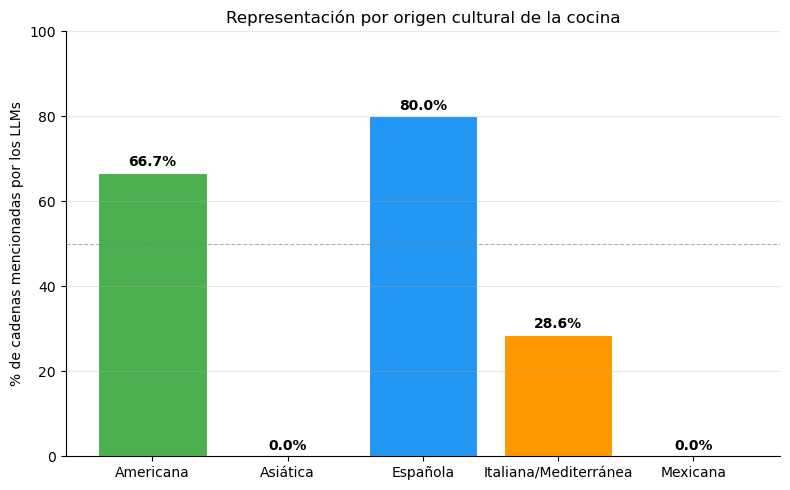

In [46]:
# Visualización
fig, ax = plt.subplots(figsize=(8, 5))

colores_origen = {
    'Española':             '#2196F3',
    'Americana':            '#4CAF50',
    'Italiana/Mediterránea':'#FF9800',
    'Asiática':             '#F44336',
    'Mexicana':             '#9C27B0',
}

bars = ax.bar(resumen['origen'],
              resumen['% mencionadas'],
              color=[colores_origen[o] for o in resumen['origen']],
              edgecolor='white', linewidth=0.8)

ax.set_ylabel('% de cadenas mencionadas por los LLMs')
ax.set_title('Representación por origen cultural de la cocina')
ax.set_ylim(0, 100)
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, val in zip(bars, resumen['% mencionadas']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('sesgo_cultural.png', dpi=150)
plt.show()

In [47]:
# Comparativa métricas digitales: asiáticas vs resto Grupo B
grupo_b = df_dig[df_dig['grupo'] == 'B'].copy()

print("=== MÉTRICAS GRUPO B POR ORIGEN ===\n")
print(grupo_b.groupby('origen')[['locales', 'DA', 'backlinks', 'instagram', 'tiktok']]\
      .mean().round(1).to_string())

print("\n=== DETALLE CADENAS ASIÁTICAS ===\n")
print(grupo_b[grupo_b['origen'] == 'Asiática']\
      [['empresa', 'locales', 'DA', 'backlinks', 'instagram']].to_string(index=False))

=== MÉTRICAS GRUPO B POR ORIGEN ===

                       locales    DA  backlinks  instagram    tiktok
origen                                                              
Americana                 70.0  37.5     9187.0   332200.0  307450.0
Asiática                  40.8  34.0     3146.0   101385.5    6224.8
Española                  32.5  38.0     2042.5   168000.0  124500.0
Italiana/Mediterránea     55.8  34.6    98102.8    46367.2   15232.2
Mexicana                  30.0  28.0     2284.0    16500.0   12900.0

=== DETALLE CADENAS ASIÁTICAS ===

   empresa  locales  DA  backlinks  instagram
Miss Sushi     23.0  43       5115      74800
    Sibuya     50.0  38       3227     263000
Buga Ramen     40.0  23        152       9942
Padthaiwok     50.0  32       4090      57800


In [48]:
print("=== TEXTO COMPLETO GPT ===\n")
print(texto_gpt)
print("\n\n=== TEXTO COMPLETO GEMINI ===\n")
print(texto_gemini)

=== TEXTO COMPLETO GPT ===

Respuestas de ChatGPT y Gemini
TFM — Factores asociados a la aparición de empresas en respuestas generadas por modelos de
lenguaje
Consultas C1–C5 · Modelos: GPT-4 y Gemini · España (sin localización concreta)
Respuestas de ChatGPT (GPT-4)
C1 Consulta:
Responde para España en general, sin tener en cuenta ninguna ubicación concreta. ¿Cuáles son las mejores
cadenas de restaurantes en España?
En España no hay una única "mejor" cadena de restaurantes, porque depende mucho de lo que busques:
precio, calidad, rapidez, ambiente o Jpo de comida. Aun así, sí hay cadenas muy consolidadas y populares que
destacan por número de locales, éxito y valoración general.
Cadenas de comida rápida (las más extendidas)
Son las más conocidas y con mayor presencia en toda España:
• McDonald's
• Burger King
• Popeyes
• KFC
Cadenas casual (muy populares en España)
Un punto intermedio entre fast food y restaurante tradicional:
• Telepizza
• La Tagliatella
• Ginos
• Foster's Hollywood


In [49]:
# Todas las empresas mencionadas en las 10 respuestas (GPT + Gemini, C1-C5)
todas_menciones = {
    # Americana
    "McDonald's":        {'origen': 'Americana',             'modelos': ['GPT','Gemini']},
    "Burger King":       {'origen': 'Americana',             'modelos': ['GPT','Gemini']},
    "KFC":               {'origen': 'Americana',             'modelos': ['GPT','Gemini']},
    "Popeyes":           {'origen': 'Americana',             'modelos': ['GPT','Gemini']},
    "Domino's Pizza":    {'origen': 'Americana',             'modelos': ['GPT','Gemini']},
    "Subway":            {'origen': 'Americana',             'modelos': ['GPT']},
    "Five Guys":         {'origen': 'Americana',             'modelos': ['Gemini']},
    "Hundred Burgers":   {'origen': 'Americana',             'modelos': ['Gemini']},
    "Fridays":           {'origen': 'Americana',             'modelos': ['GPT']},
    "Tony Roma's":       {'origen': 'Americana',             'modelos': ['Gemini']},
    "Starbucks":         {'origen': 'Americana',             'modelos': ['Gemini']},
    "Papa John's":       {'origen': 'Americana',             'modelos': ['Gemini']},
    "Taco Bell":         {'origen': 'Mexicana/Americana',    'modelos': ['Gemini']},
    # Española
    "100 Montaditos":    {'origen': 'Española',              'modelos': ['GPT','Gemini']},
    "Telepizza":         {'origen': 'Española',              'modelos': ['GPT','Gemini']},
    "VIPS":              {'origen': 'Española',              'modelos': ['GPT','Gemini']},
    "Rodilla":           {'origen': 'Española',              'modelos': ['GPT','Gemini']},
    "Lizarran":          {'origen': 'Española',              'modelos': ['GPT','Gemini']},
    "La Sureña":         {'origen': 'Española',              'modelos': ['GPT','Gemini']},
    "Pans & Company":    {'origen': 'Española',              'modelos': ['GPT','Gemini']},
    "Goiko":             {'origen': 'Española',              'modelos': ['GPT','Gemini']},
    "TGB":               {'origen': 'Española',              'modelos': ['GPT','Gemini']},
    "Lateral":           {'origen': 'Española',              'modelos': ['GPT']},
    "FoodBox":           {'origen': 'Española',              'modelos': ['GPT']},
    "Granier":           {'origen': 'Española',              'modelos': ['GPT']},
    "Santagloria":       {'origen': 'Española',              'modelos': ['GPT']},
    "Manolo Bakes":      {'origen': 'Española',              'modelos': ['Gemini']},
    "Honest Greens":     {'origen': 'Española',              'modelos': ['Gemini']},
    "Grosso Napoletano": {'origen': 'Española',              'modelos': ['Gemini']},
    "Saona":             {'origen': 'Española',              'modelos': ['Gemini']},
    "Tierra Burrito":    {'origen': 'Española',              'modelos': ['Gemini']},
    "Kilómetros de Pizza":{'origen': 'Española',             'modelos': ['Gemini']},
    # Italiana/Mediterránea
    "La Tagliatella":    {'origen': 'Italiana/Mediterránea', 'modelos': ['GPT','Gemini']},
    "Ginos":             {'origen': 'Italiana/Mediterránea', 'modelos': ['GPT','Gemini']},
    "Foster's Hollywood":{'origen': 'Italiana/Mediterránea', 'modelos': ['GPT','Gemini']},
    # Asiática
    "Udon Asian Food":   {'origen': 'Asiática',              'modelos': ['Gemini']},
    "Aloha Poké":        {'origen': 'Asiática',              'modelos': ['GPT']},
}

df_todas = pd.DataFrame([
    {'empresa': k, 'origen': v['origen'], 'n_modelos': len(v['modelos'])}
    for k, v in todas_menciones.items()
])

resumen_total = df_todas.groupby('origen').agg(
    cadenas_mencionadas=('empresa', 'count')
).reset_index()
resumen_total['%'] = (resumen_total['cadenas_mencionadas'] /
                      resumen_total['cadenas_mencionadas'].sum() * 100).round(1)
resumen_total = resumen_total.sort_values('cadenas_mencionadas', ascending=False)
print(resumen_total.to_string(index=False))
print(f"\nTotal cadenas únicas mencionadas: {len(df_todas)}")
print(f"Cadenas asiáticas: {len(df_todas[df_todas['origen']=='Asiática'])} "
      f"({df_todas[df_todas['origen']=='Asiática']['empresa'].tolist()})")
print(f"Solo aparecen en C1, en ninguna otra consulta.")

               origen  cadenas_mencionadas    %
             Española                   19 51.4
            Americana                   12 32.4
Italiana/Mediterránea                    3  8.1
             Asiática                    2  5.4
   Mexicana/Americana                    1  2.7

Total cadenas únicas mencionadas: 37
Cadenas asiáticas: 2 (['Udon Asian Food', 'Aloha Poké'])
Solo aparecen en C1, en ninguna otra consulta.


/var/folders/h5/nhh63hdj0zq4fpwbcxyxr1lh0000gn/T/ipykernel_70515/3638976874.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(res['origen'], rotation=15, ha='right', fontsize=9)
/var/folders/h5/nhh63hdj0zq4fpwbcxyxr1lh0000gn/T/ipykernel_70515/3638976874.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(origenes, rotation=15, ha='right', fontsize=9)


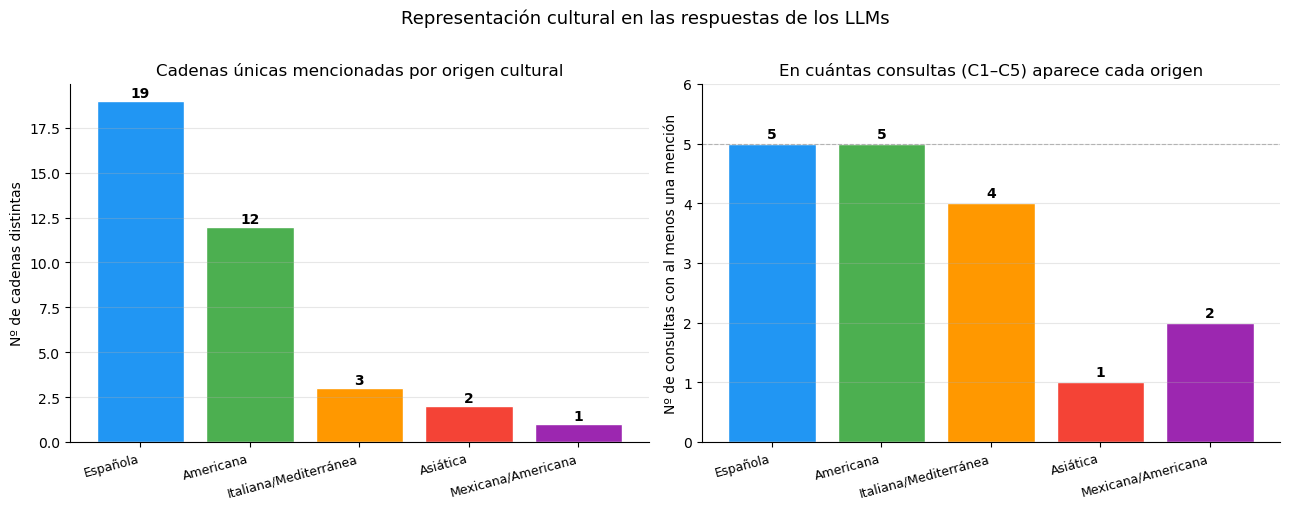

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico 1: distribución por origen del total de menciones
colores_barras = {
    'Española':             '#2196F3',
    'Americana':            '#4CAF50',
    'Italiana/Mediterránea':'#FF9800',
    'Asiática':             '#F44336',
    'Mexicana/Americana':   '#9C27B0',
}
res = resumen_total.copy()
bars = axes[0].bar(res['origen'], res['cadenas_mencionadas'],
                   color=[colores_barras[o] for o in res['origen']],
                   edgecolor='white')
axes[0].set_title('Cadenas únicas mencionadas por origen cultural', fontsize=12)
axes[0].set_ylabel('Nº de cadenas distintas')
axes[0].set_xticklabels(res['origen'], rotation=15, ha='right', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for bar, val in zip(bars, res['cadenas_mencionadas']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(val), ha='center', fontsize=10, fontweight='bold')

# Gráfico 2: en qué consultas aparece cada origen
consultas_por_origen = {
    'Española':             5,
    'Americana':            5,
    'Italiana/Mediterránea':4,
    'Asiática':             1,
    'Mexicana/Americana':   2,
}
origenes = list(consultas_por_origen.keys())
vals     = list(consultas_por_origen.values())
bars2 = axes[1].bar(origenes, vals,
                    color=[colores_barras[o] for o in origenes],
                    edgecolor='white')
axes[1].set_title('En cuántas consultas (C1–C5) aparece cada origen', fontsize=12)
axes[1].set_ylabel('Nº de consultas con al menos una mención')
axes[1].set_ylim(0, 6)
axes[1].set_xticklabels(origenes, rotation=15, ha='right', fontsize=9)
axes[1].axhline(5, color='gray', linestyle='--', lw=0.8, alpha=0.5, label='Máximo posible')
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for bar, val in zip(bars2, vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(val), ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Representación cultural en las respuestas de los LLMs', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('sesgo_cultural_completo.png', dpi=150)
plt.show()

## 13. Análisis de representación cultural en las respuestas de los LLMs

Con el objetivo de explorar si existe algún patrón de sesgo cultural en las 
respuestas generadas, se identificaron y clasificaron todas las cadenas únicas 
mencionadas por ChatGPT y Gemini a lo largo de las cinco consultas, con 
independencia de si formaban parte del corpus del estudio.

En total, ambos modelos mencionaron 37 cadenas distintas a lo largo de las 10 
respuestas. De ellas, 19 son de origen español (51.4%), 12 de origen americano 
(32.4%), 3 de cocina italiana o mediterránea (8.1%) y únicamente 2 de cocina 
asiática (5.4%): Udon Asian Food, mencionada por Gemini en C1, y Aloha Poké, 
mencionada por GPT también en C1. Ninguna cadena de cocina asiática aparece 
en las consultas C2, C3, C4 o C5.

Este patrón resulta especialmente llamativo si se compara con cadenas como 
Rodilla, que con 200 locales y métricas digitales modestas aparece mencionada 
en ambos modelos y en varias consultas, mientras que cadenas asiáticas con 
presencia digital comparable —como Miss Sushi (DA=43) o Sibuya (263.000 
seguidores en Instagram)— no reciben ninguna mención en ninguna de las 
10 respuestas analizadas.

Estos resultados apuntan a una posible infrarrepresentación de la cocina asiática 
en los LLMs cuando se consulta sobre restauración en España, coherente con la 
literatura sobre sesgos culturales en modelos de lenguaje. Dado el tamaño 
muestral del estudio, este hallazgo debe interpretarse como exploratorio y no 
como evidencia concluyente, pero abre una línea de investigación relevante sobre 
cómo los modelos de lenguaje reproducen o amplifican sesgos de representación 
cultural en sus recomendaciones.

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Matriz de correlación de todas las variables digitales
vars_nombres = ['Año llegada', 'Nº locales', 'Domain Authority', 'Backlinks',
                'Instagram', 'TikTok', 'Wikipedia ES', 'Wikipedia EN', 'Wikidata']

df_corr = pd.DataFrame(X, columns=vars_nombres)
df_corr['Mencionada'] = y

corr_matrix = df_corr.corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            ax=ax, cbar_kws={'shrink': 0.8})

ax.set_title('Matriz de correlación de Spearman — Variables digitales + mención',
             fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('matriz_correlacion.png', dpi=150)
plt.show()

ValueError: Length of values (14) does not match length of index (28)

La matriz de correlación de Spearman permite visualizar las relaciones entre 
todas las variables digitales del estudio y su asociación con la variable 
objetivo (mención por los LLMs).

La variable con mayor correlación con ser mencionada es el número de locales 
(ρ=0.85), seguida de Wikidata (ρ=0.80), Wikipedia ES (ρ=0.79), Domain 
Authority (ρ=0.72) y Backlinks (ρ=0.59). Este patrón es totalmente coherente 
con los resultados del análisis SHAP, confirmando que la presencia física y 
la indexación en fuentes de conocimiento estructurado son los factores con mayor peso en este análisis.
Destaca también la alta correlación entre Wikipedia ES y Wikidata (ρ=0.86), 
lo que sugiere que ambas variables capturan un mismo fenómeno subyacente: 
la consolidación institucional de la marca en el ecosistema de conocimiento 
que alimenta los LLMs.

Por el contrario, Instagram (ρ=0.39) y TikTok (ρ=0.38) presentan las 
correlaciones más bajas con la mención, lo que refuerza la idea de que la 
popularidad en redes sociales no se traduce en mayor visibilidad en las 
respuestas de los modelos de lenguaje. El año de llegada a España muestra 
una correlación negativa (ρ=-0.31), indicando que las cadenas más antiguas 
tienen ligeramente más presencia en los LLMs, aunque el efecto es moderado.

grupo_empresarial  total  mencionadas  no_mencionadas  % mencionadas
            Alsea      4            4               0          100.0
    Independiente     22            8              14           36.4
         Restalia      2            2               0          100.0


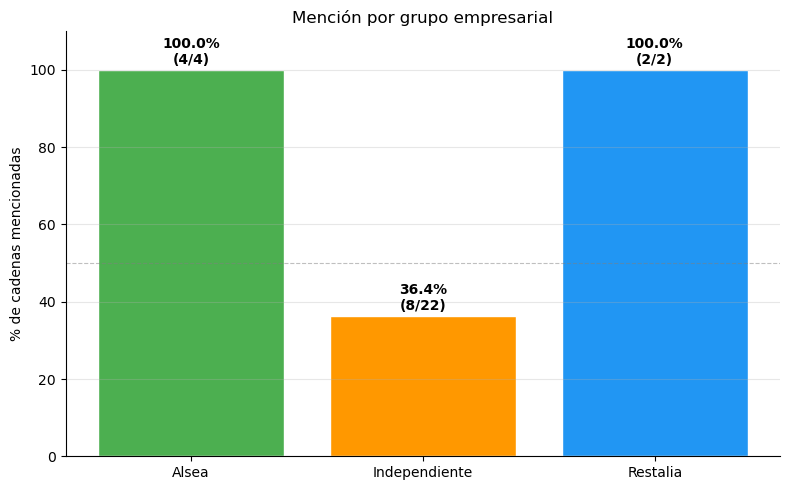

In [53]:
# Análisis de grupos empresariales
grupos_empresariales = {
    '100 Montaditos':               'Restalia',
    'The Good Burger (TGB)':        'Restalia',
    'VIPS':                         'Alsea',
    'Ginos':                        'Alsea',
    "Foster's Hollywood":           'Alsea',
    "Domino's Pizza":               'Alsea',
    'KFC':                          'Independiente',
    'Telepizza':                    'Independiente',
    'Goiko':                        'Independiente',
    'La Tagliatella':               'Independiente',
    'Rodilla':                      'Independiente',
    'Lizarran':                     'Independiente',
    'Popeyes':                      'Independiente',
    'Taco Bell':                    'Independiente',
    'Muerde la Pasta':              'Independiente',
    'La Mafia se sienta a la mesa': 'Independiente',
    'Papizza':                      'Independiente',
    'Ribs':                         'Independiente',
    'Pomodoro':                     'Independiente',
    'Vicio':                        'Independiente',
    'Miss Sushi':                   'Independiente',
    'Sibuya':                       'Independiente',
    'Pizza Hut':                    'Independiente',
    'Buga Ramen':                   'Independiente',
    'Cantina Mariachi':             'Independiente',
    'O Mamma Mia':                  'Independiente',
    'Padthaiwok':                   'Independiente',
    "Papa John's":                  'Independiente',
}

df_dig['grupo_empresarial'] = df_dig['empresa'].map(grupos_empresariales)

resumen_ge = df_dig.groupby('grupo_empresarial').agg(
    total=('empresa', 'count'),
    mencionadas=('mencionada', 'sum')
).reset_index()
resumen_ge['no_mencionadas'] = resumen_ge['total'] - resumen_ge['mencionadas']
resumen_ge['% mencionadas'] = (resumen_ge['mencionadas'] /
                                resumen_ge['total'] * 100).round(1)
print(resumen_ge.to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(8, 5))
colores_ge = {'Restalia': '#2196F3', 'Alsea': '#4CAF50', 'Independiente': '#FF9800'}

bars = ax.bar(resumen_ge['grupo_empresarial'],
              resumen_ge['% mencionadas'],
              color=[colores_ge[g] for g in resumen_ge['grupo_empresarial']],
              edgecolor='white')

ax.set_ylabel('% de cadenas mencionadas')
ax.set_title('Mención por grupo empresarial')
ax.set_ylim(0, 110)
ax.axhline(50, color='gray', linestyle='--', lw=0.8, alpha=0.5)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, row in zip(bars, resumen_ge.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{row._5}%\n({row.mencionadas}/{row.total})",
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('grupos_empresariales.png', dpi=150)
plt.show()

El análisis por grupo empresarial revela uno de los hallazgos más llamativos 
del estudio. Las seis cadenas pertenecientes a los dos grandes grupos de 
restauración en España —Alsea (VIPS, Ginos, Foster's Hollywood, Domino's Pizza) 
y Restalia (100 Montaditos, The Good Burger)— son mencionadas en el 100% de 
los casos. Por el contrario, solo el 36.4% de las cadenas independientes 
aparecen en las respuestas de los modelos.

Este patrón sugiere que los LLMs no solo recogen información sobre cadenas 
individuales sino que reproducen la estructura corporativa del sector: cuando 
mencionan una marca de Alsea o Restalia tienden a mencionar también las demás 
del mismo grupo, posiblemente porque en sus datos de entrenamiento estas marcas 
aparecen frecuentemente asociadas bajo el paraguas de su grupo matriz.

Desde el punto de vista práctico, este hallazgo tiene implicaciones relevantes 
para las empresas independientes: competir en visibilidad con cadenas respaldadas 
por grandes grupos de restauración no solo implica superar su presencia digital, 
sino también la ventaja estructural que les otorga pertenecer a un ecosistema 
corporativo bien documentado en las fuentes que alimentan los LLMs.

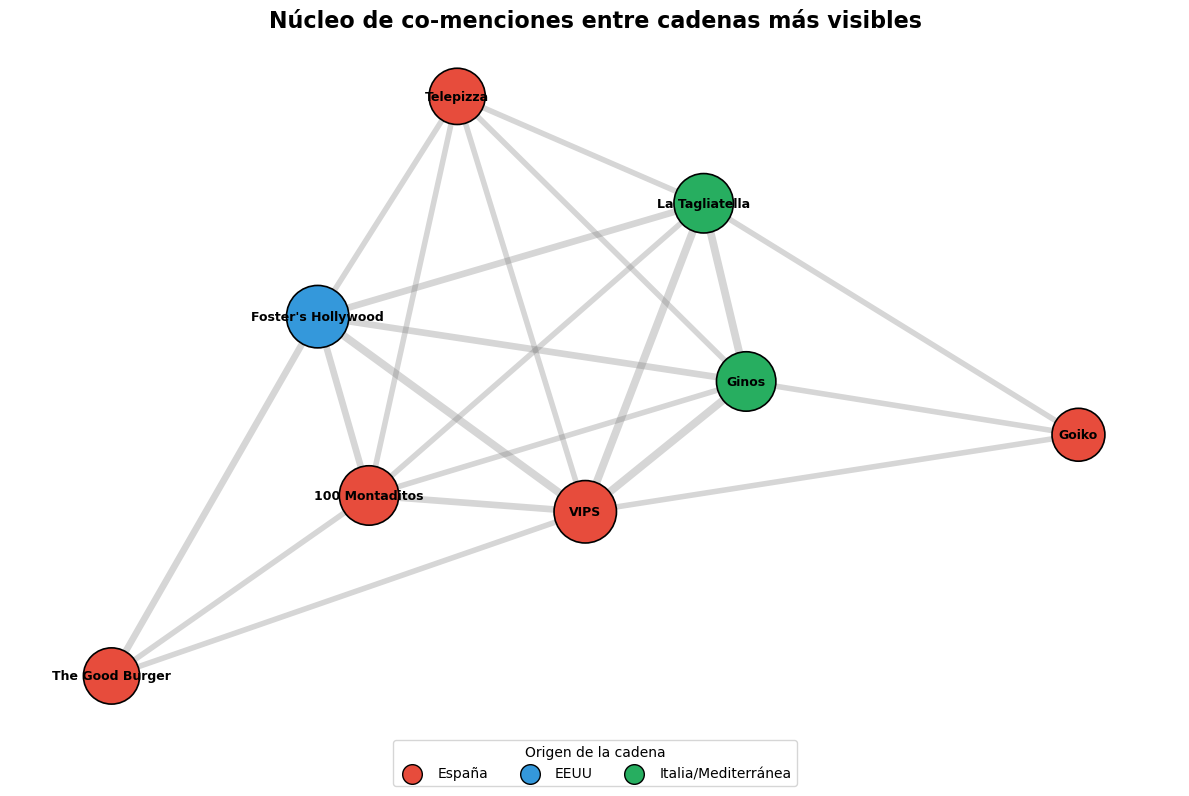

In [54]:
import itertools
from collections import Counter
import networkx as nx
import matplotlib.pyplot as plt

mentions = {
    "GPT C1": ["Popeyes", "KFC", "Telepizza", "La Tagliatella", "Ginos", "Foster's Hollywood",
               "100 Montaditos", "Lizarran", "VIPS"],
    "GPT C2": [],
    "GPT C3": ["Telepizza", "100 Montaditos", "Rodilla", "La Tagliatella", "Foster's Hollywood",
               "VIPS", "Ginos", "The Good Burger", "Lizarran"],
    "GPT C4": ["Foster's Hollywood", "VIPS", "La Tagliatella", "Ginos", "Goiko",
               "The Good Burger", "KFC", "Domino's Pizza", "Telepizza"],
    "GPT C5": ["KFC", "100 Montaditos", "Telepizza", "Foster's Hollywood",
               "Domino's Pizza", "The Good Burger"],

    "Gemini C1": ["VIPS", "Ginos", "Foster's Hollywood", "100 Montaditos",
                  "The Good Burger", "Goiko", "Popeyes", "Taco Bell", "La Tagliatella"],
    "Gemini C2": ["100 Montaditos", "The Good Burger", "VIPS", "Foster's Hollywood"],
    "Gemini C3": ["100 Montaditos", "The Good Burger", "Rodilla", "Telepizza", "Goiko",
                  "VIPS", "Ginos", "La Tagliatella", "Foster's Hollywood",
                  "Lizarran", "Domino's Pizza", "Popeyes"],
    "Gemini C4": ["VIPS", "La Tagliatella", "Goiko", "Foster's Hollywood", "Ginos"],
    "Gemini C5": ["Telepizza", "KFC", "100 Montaditos", "Rodilla", "VIPS",
                  "Goiko", "Taco Bell", "La Tagliatella", "Ginos", "Domino's Pizza"]
}

origin = {
    "100 Montaditos": "España",
    "Foster's Hollywood": "EEUU",
    "VIPS": "España",
    "La Tagliatella": "Italia/Mediterránea",
    "Ginos": "Italia/Mediterránea",
    "Telepizza": "España",
    "The Good Burger": "España",
    "KFC": "EEUU",
    "Goiko": "España",
    "Domino's Pizza": "EEUU",
    "Rodilla": "España",
    "Lizarran": "España",
    "Popeyes": "EEUU",
    "Taco Bell": "EEUU"
}

colors = {
    "España": "#e74c3c",
    "EEUU": "#3498db",
    "Italia/Mediterránea": "#27ae60"
}

# Frecuencias
node_freq = Counter()
edge_weights = Counter()

for companies in mentions.values():
    companies = sorted(set(companies))
    node_freq.update(companies)
    for a, b in itertools.combinations(companies, 2):
        edge_weights[(a, b)] += 1

# Grafo
G = nx.Graph()

for company in origin:
    G.add_node(company, origin=origin[company], freq=node_freq[company])

# Solo co-menciones MUY fuertes: aparecen juntas en 5 o más respuestas
for (a, b), w in edge_weights.items():
    if w >= 5:
        G.add_edge(a, b, weight=w)

# Quitar nodos aislados para que el grafo explique núcleo, no ruido
G.remove_nodes_from(list(nx.isolates(G)))

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, seed=10, k=1.25, weight="weight")

node_sizes = [500 + G.nodes[n]["freq"] * 190 for n in G.nodes()]
node_colors = [colors[G.nodes[n]["origin"]] for n in G.nodes()]
edge_widths = [G[u][v]["weight"] * 0.8 for u, v in G.edges()]

nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    alpha=0.32,
    edge_color="gray"
)

nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors="black",
    linewidths=1.2
)

nx.draw_networkx_labels(
    G, pos,
    font_size=9,
    font_weight="bold"
)

plt.title(
    "Núcleo de co-menciones entre cadenas más visibles",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

for label, color in colors.items():
    plt.scatter([], [], c=color, s=200, label=label, edgecolors="black")

plt.legend(
    title="Origen de la cadena",
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.08)
)

plt.tight_layout()
plt.savefig("figura_nucleo_comenciones.png", dpi=300, bbox_inches="tight")
plt.show()